# TimesFM Forecast & Anomaly Visualization

Plots actual vs forecasted values with prediction intervals, and the aggregated anomaly score overlaid with ground-truth anomaly labels.

### Imports and Model Loading

In [43]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
from scipy.ndimage import uniform_filter1d

import timesfm
from timesfm.timesfm_2p5.timesfm_2p5_torch import TimesFM_2p5_200M_torch

torch.set_float32_matmul_precision("high")

# Reuse the helpers from our pipeline so the visualization matches the eval pipeline exactly.
from timesFM_modularised import (
    load_model,
    load_and_prepare,
    generate_prediction,
    compute_feature_score,
    aggregate_scores,
    robust_normalize,
)

model = load_model("./timesfm-weights")

### Configuration

Set the file to visualize and the model/scoring config. Defaults match the modularized pipeline.

In [44]:
CSV_PATH          = "./mTSBench/SMD/SMD_machine-1-4_test.csv"
CONTEXT_LENGTH    = 512
HORIZON           = 128
WINDOWS_PER_BATCH = 10
SCORE_METHOD      = "interval"   # 'mse', 'interval', 'normalized_deviation', 'smape'
AGG_METHOD        = "l2"         # 'l2', 'max', 'mean', 'topk_mean'

### Load Data

In [45]:
df, feature_list, label, n_total, n_dim = load_and_prepare(CSV_PATH)
print(f"file:          {os.path.basename(CSV_PATH)}")
print(f"n_total:       {n_total}")
print(f"n_features:    {n_dim}")
print(f"n_anomalies:   {label.sum()} ({100*label.mean():.2f}%)")
print(f"first feature: {feature_list[0]}")

file:          SMD_machine-1-4_test.csv
n_total:       10084
n_features:    38
n_anomalies:   409 (4.06%)
first feature: feature_1


### Generate Predictions

Runs the same batched walk-forward forecast as `process_file` in the pipeline. Forecasts cover indices `[CONTEXT_LENGTH, n_total)`.

In [46]:
prediction_df = generate_prediction(
    model, df, feature_list, n_total,
    CONTEXT_LENGTH, HORIZON, WINDOWS_PER_BATCH,
)

# Group by feature so per-feature plots are cheap (no repeated groupby).
feature_groups = {
    feature: group.sort_values("t_idx").reset_index(drop=True)
    for feature, group in prediction_df.groupby("target_name")
}

print(f"prediction_df rows: {len(prediction_df):,}")
print(f"forecast region:    [{CONTEXT_LENGTH}, {n_total})  ({n_total - CONTEXT_LENGTH} timesteps)")
print(f"features grouped:   {len(feature_groups)}")

prediction_df rows: 363,736
forecast region:    [512, 10084)  (9572 timesteps)
features grouped:   38


### Compute Anomaly Score

Per-feature score → robust percentile normalization → L2 aggregation across features. Same recipe as the pipeline.

In [47]:
# Per-feature anomaly scores aligned to the forecast region.
anomaly_scores = {}
for feature_name, group_df in feature_groups.items():
    t_start = int(group_df["t_idx"].iloc[0])
    t_end   = int(group_df["t_idx"].iloc[-1]) + 1
    y_actual = df[feature_name].iloc[t_start:t_end].to_numpy(dtype=np.float32)
    anomaly_scores[feature_name] = compute_feature_score(
        y_actual, group_df, method=SCORE_METHOD
    )

anomaly_df = pd.DataFrame(anomaly_scores)

# sMAPE is already scale-invariant; everything else gets robust-normalized per feature.
if SCORE_METHOD != "smape":
    anomaly_df = anomaly_df.apply(
        lambda col: pd.Series(robust_normalize(col.values)), axis=0
    )
anomaly_df = anomaly_df.fillna(0)

y_score = aggregate_scores(anomaly_df, method=AGG_METHOD)
y_score = np.asarray(y_score)  # handle Series-returning aggregations uniformly
y_true_forecast_region = label[CONTEXT_LENGTH:]

auroc = roc_auc_score(y_true_forecast_region, y_score) if y_true_forecast_region.sum() > 0 else float("nan")
auprc = average_precision_score(y_true_forecast_region, y_score) if y_true_forecast_region.sum() > 0 else float("nan")
print(f"AUROC: {auroc:.4f} | AUPRC: {auprc:.4f}")

AUROC: 0.7320 | AUPRC: 0.2099


In [48]:
# Indices where anomalies start, within the forecast region.
label_forecast = label[CONTEXT_LENGTH:]
anomaly_starts = np.where(np.diff(label_forecast.astype(int)) == 1)[0] + 1

# Show the first 10 anomaly events with their durations.
for s in anomaly_starts[:10]:
    # Find run length.
    e = s
    while e < len(label_forecast) and label_forecast[e] == 1:
        e += 1
    print(f"  anomaly at [{s}, {e})  duration={e - s}")

  anomaly at [2105, 2126)  duration=21
  anomaly at [2925, 3062)  duration=137
  anomaly at [3495, 3583)  duration=88
  anomaly at [4325, 4346)  duration=21
  anomaly at [6058, 6098)  duration=40
  anomaly at [8835, 8881)  duration=46
  anomaly at [9083, 9086)  duration=3


### Plot Function

Two-panel layout mirroring the senior's visualization:
- **Top**: actual + predicted median + q10/q90 prediction interval
- **Bottom**: scaled anomaly score (blue) + ground-truth `is_anomaly` (red, step)

`smooth_window` applies a centered rolling mean to the four lines (predicted, q10, q90, y_score). Set to 1 to disable.

In [49]:
def plot_forecast_with_anomaly(
    feature_groups, df, y_score, label, feature_list,
    feature_idx=1, plot_from=None, plot_until=None, smooth_window=100,
    context_length=CONTEXT_LENGTH,
):
    """Plot one feature's forecast + the file's aggregated anomaly score.

    feature_groups: dict[feature_name -> DataFrame with '0.1','0.5','0.9','t_idx'].
    df:             the full input DataFrame (no train/test split).
    y_score:        1D array of length (n_total - context_length).
    label:          1D 0/1 array of length n_total (ground truth anomaly).
    feature_idx:    index into the visible feature list.
    plot_from/until: slice bounds within the forecast region (relative to its start).
    smooth_window:  rolling-mean width applied to predicted/q10/q90/y_score.
    """
    
  
    feature_col  = feature_list[feature_idx]

    feat_df    = feature_groups[feature_col]
    predicted  = feat_df["0.5"].values
    q_low      = feat_df["0.1"].values
    q_high     = feat_df["0.9"].values

    # Align actual + anomaly label + score to the forecast region.
    actual         = df[feature_col].values[-len(predicted):]
    is_anomaly     = label[-len(predicted):]
    y_score_arr    = np.asarray(y_score)[-len(predicted):]
    time           = np.arange(len(predicted))

    # Min-max scale the score so it sits cleanly in the bottom panel.
    smin, smax = y_score_arr.min(), y_score_arr.max()
    if smax - smin > 1e-12:
        y_score_scaled = (y_score_arr - smin) / (smax - smin)
    else:
        y_score_scaled = np.zeros_like(y_score_arr)

    start = plot_from  if plot_from  is not None else 0
    end   = plot_until if plot_until is not None else len(predicted)

    # Smooth before slicing so the rolling mean uses full-window context near the edges.
    if smooth_window > 1:
        def _smooth(a):
            return pd.Series(a).rolling(smooth_window, center=True, min_periods=1).mean().values
        predicted      = _smooth(predicted)
        q_low          = _smooth(q_low)
        q_high         = _smooth(q_high)
        y_score_scaled = _smooth(y_score_scaled)

    # Crop everything to the requested view.
    predicted      = predicted[start:end]
    actual         = actual[start:end]
    is_anomaly     = is_anomaly[start:end]
    q_low          = q_low[start:end]
    q_high         = q_high[start:end]
    y_score_scaled = y_score_scaled[start:end]
    time           = time[start:end]

    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(16, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [4, 1]},
    )
    fig.suptitle(f" {feature_col} ", fontsize=10, fontweight="bold")

    ax1.plot(time, actual,    label="Actual",    color="steelblue",  linewidth=1.2)
    ax1.plot(time, predicted, label="Predicted", color="darkorange", linewidth=1.2, linestyle="--")
    ax1.fill_between(
        time, q_low, q_high,
        alpha=0.3, color="xkcd:light lavender",
        label="prediction interval (0.1–0.9)",
    )
    ax1.set_ylabel("Value")
    ax1.legend(loc="upper left")
    ax1.grid(True, linestyle="--", alpha=0.4)

    ax2.plot(time, y_score_scaled, color="steelblue", linewidth=1.0, label="anomaly score")
    ax2.fill_between(time, y_score_scaled, alpha=0.15, color="steelblue")
    ax2.fill_between(time, is_anomaly, step="mid", color="red", alpha=0.3,
                     label="is_anomaly (ground truth)")
    ax2.plot(time, is_anomaly, color="red", linewidth=0.8,
             drawstyle="steps-mid", alpha=0.6)
    ax2.set_ylabel("Score / Anomaly")
    ax2.set_ylim(-0.1, 1.5)
    ax2.set_yticks([0, 0.5, 1])
    ax2.set_xlabel("timestamp (relative to forecast start)")
    ax2.grid(True, linestyle="--", alpha=0.4)

    plt.tight_layout()
    plt.show()

### Single Feature, Zoomed View

Pick a feature and a window. Useful for finding what the model gets right or wrong around a specific anomaly event.

**Tip**: to find a good `plot_from`/`plot_until` zoom, look for anomaly clusters in the label array first:
```python
anomaly_starts = np.where(np.diff(label[CONTEXT_LENGTH:].astype(int)) == 1)[0]
print(anomaly_starts[:10])  # pick one and zoom around it
```

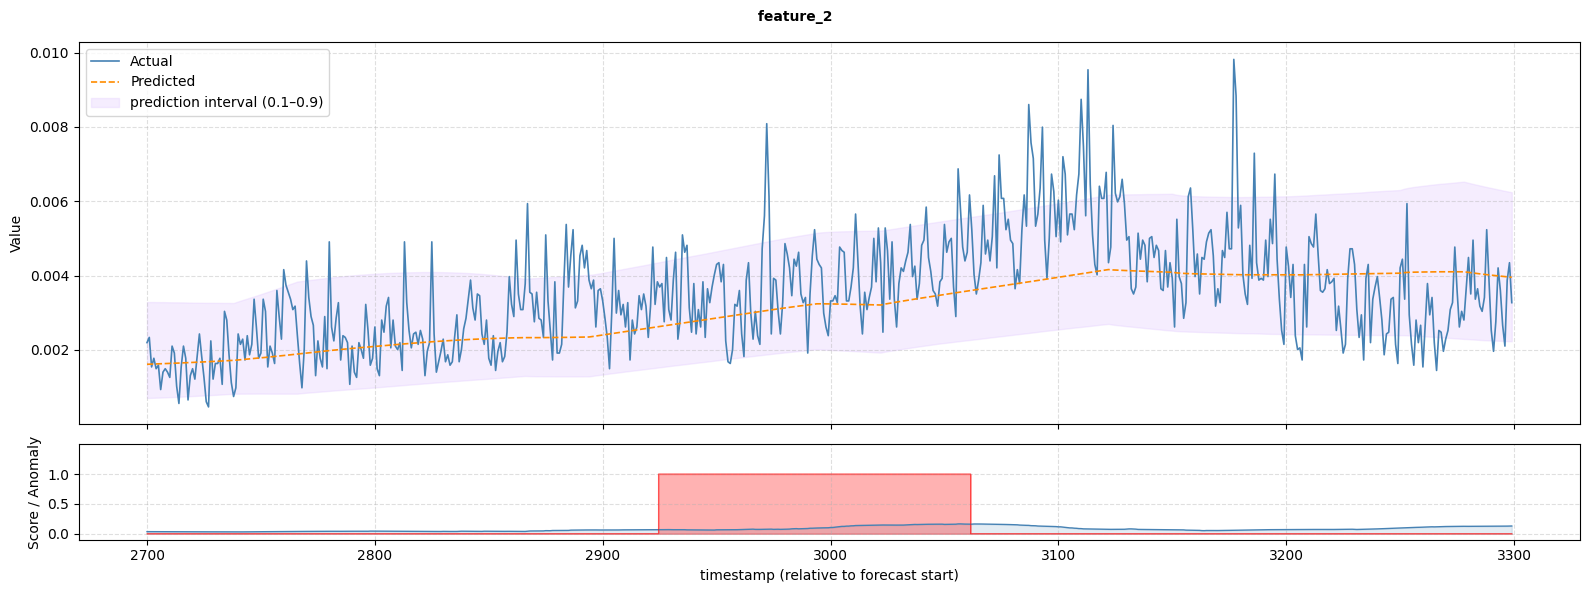

In [50]:
plot_forecast_with_anomaly(
    feature_groups, df, y_score, label, feature_list,
    feature_idx=1,
    plot_from=2700,
    plot_until=3300,
    smooth_window=100,
)

### All Features, Same Zoom Window

Loops over every feature with the same view bounds — useful for spotting which features actually carry the anomaly signal.

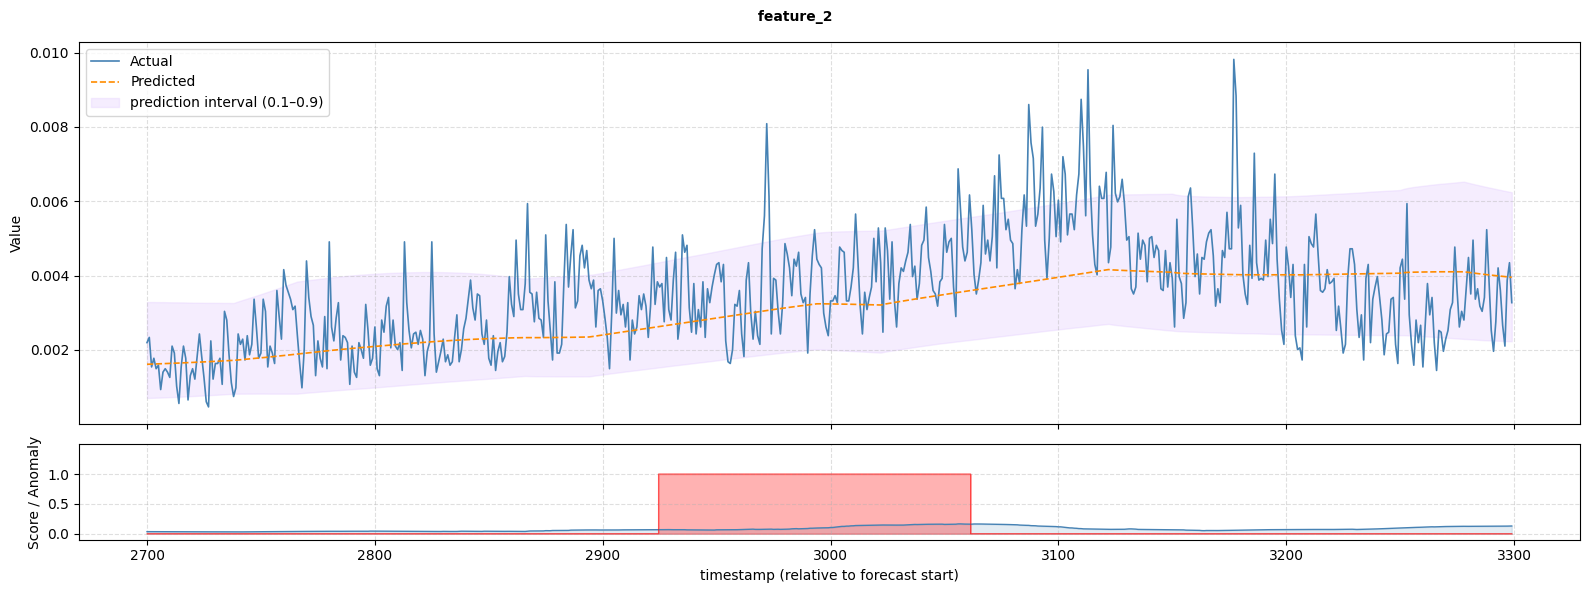

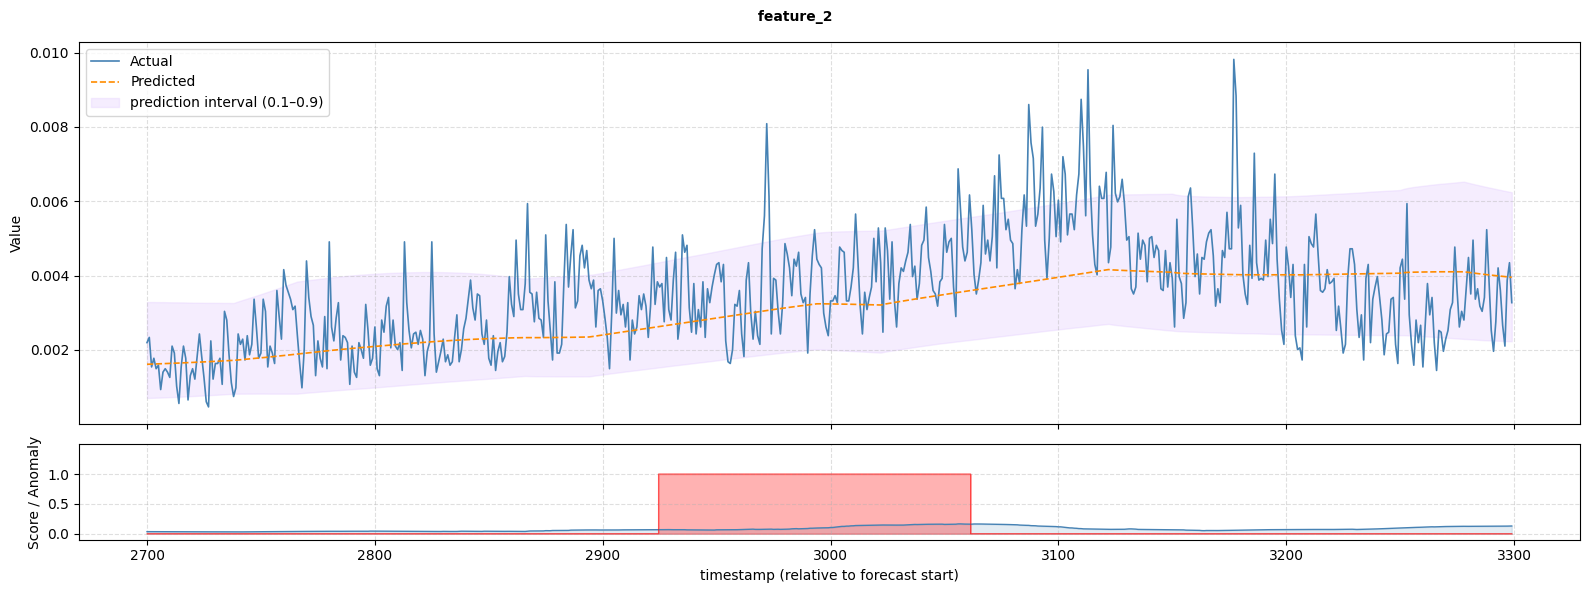

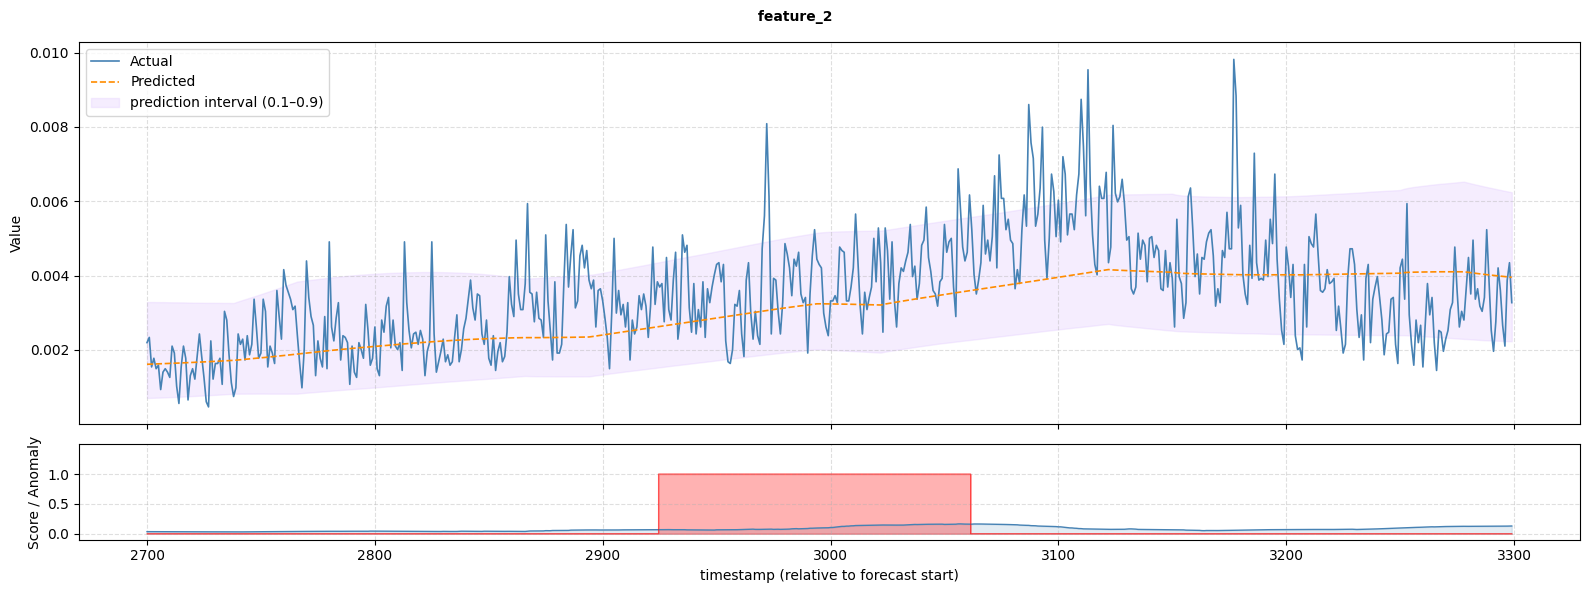

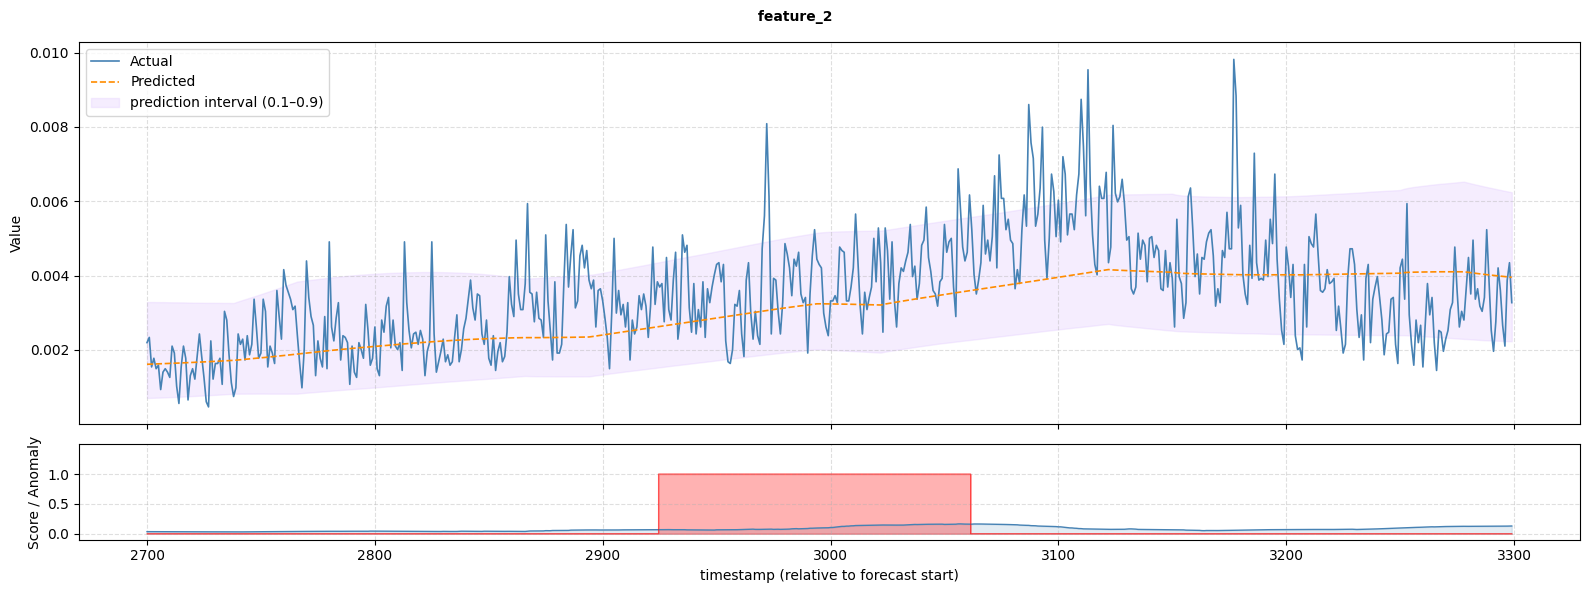

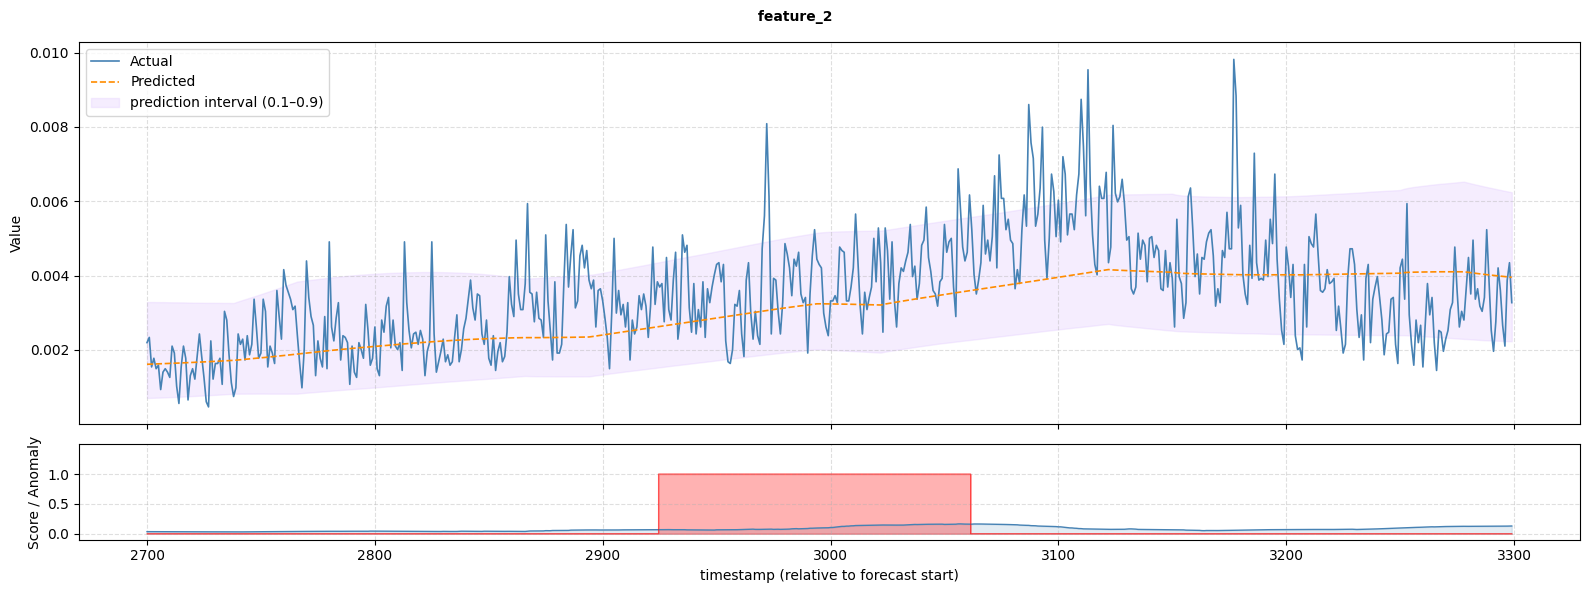

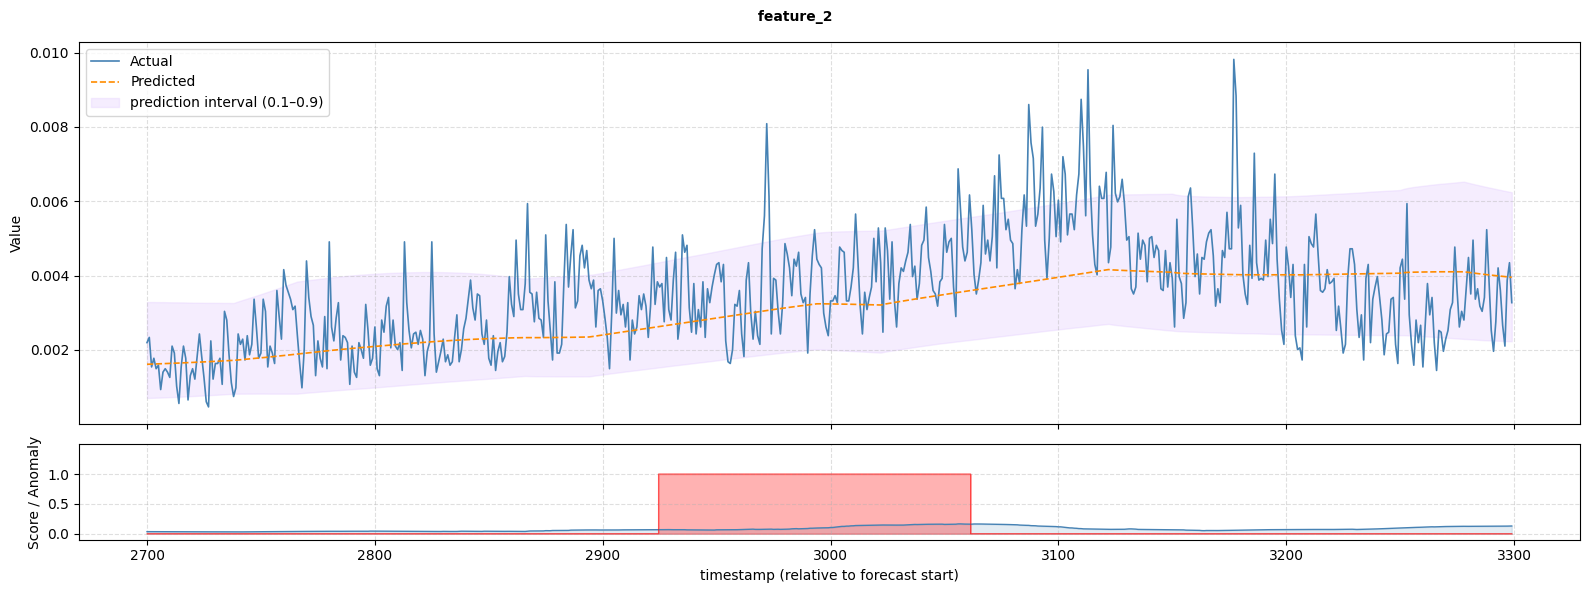

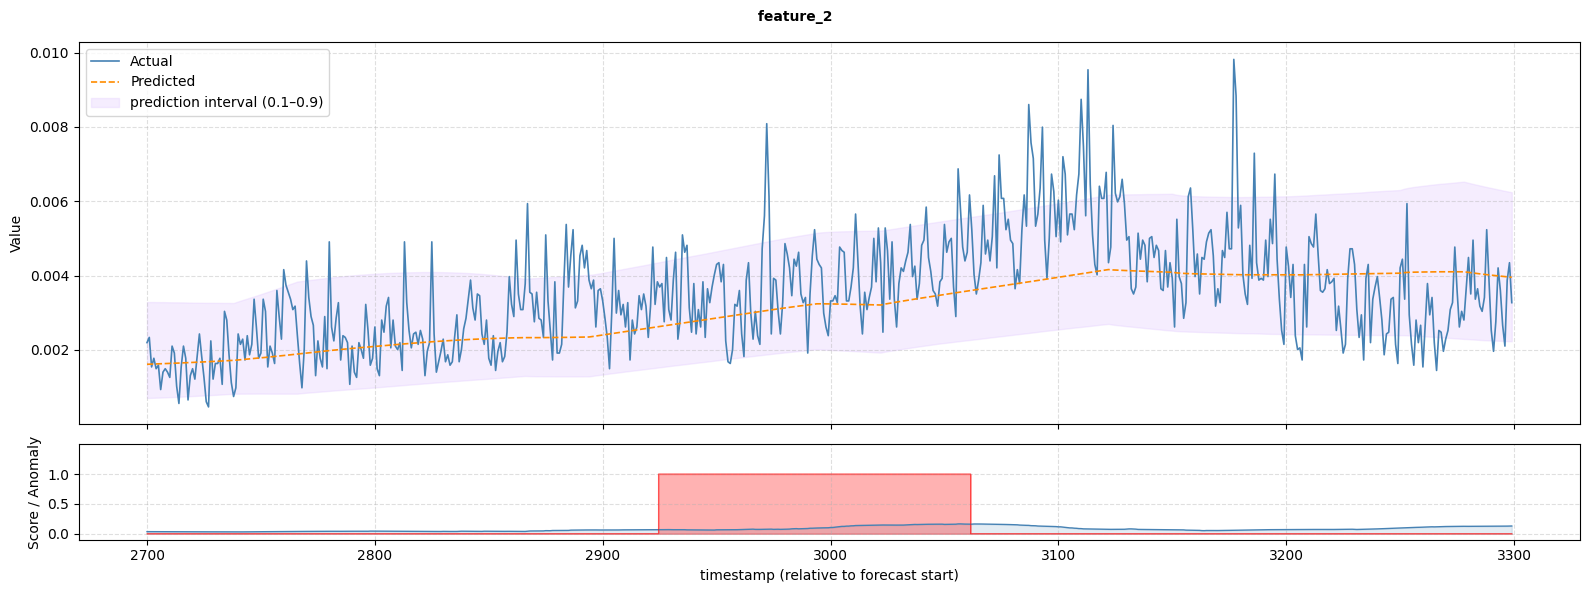

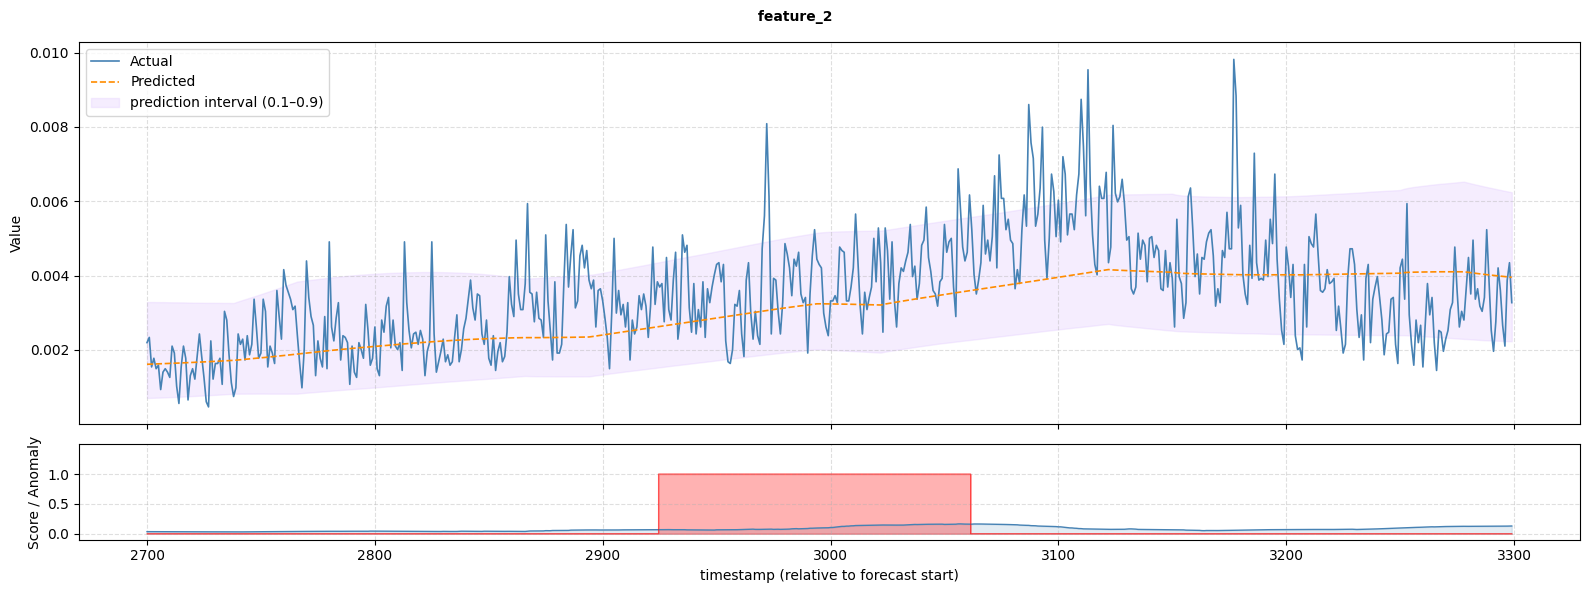

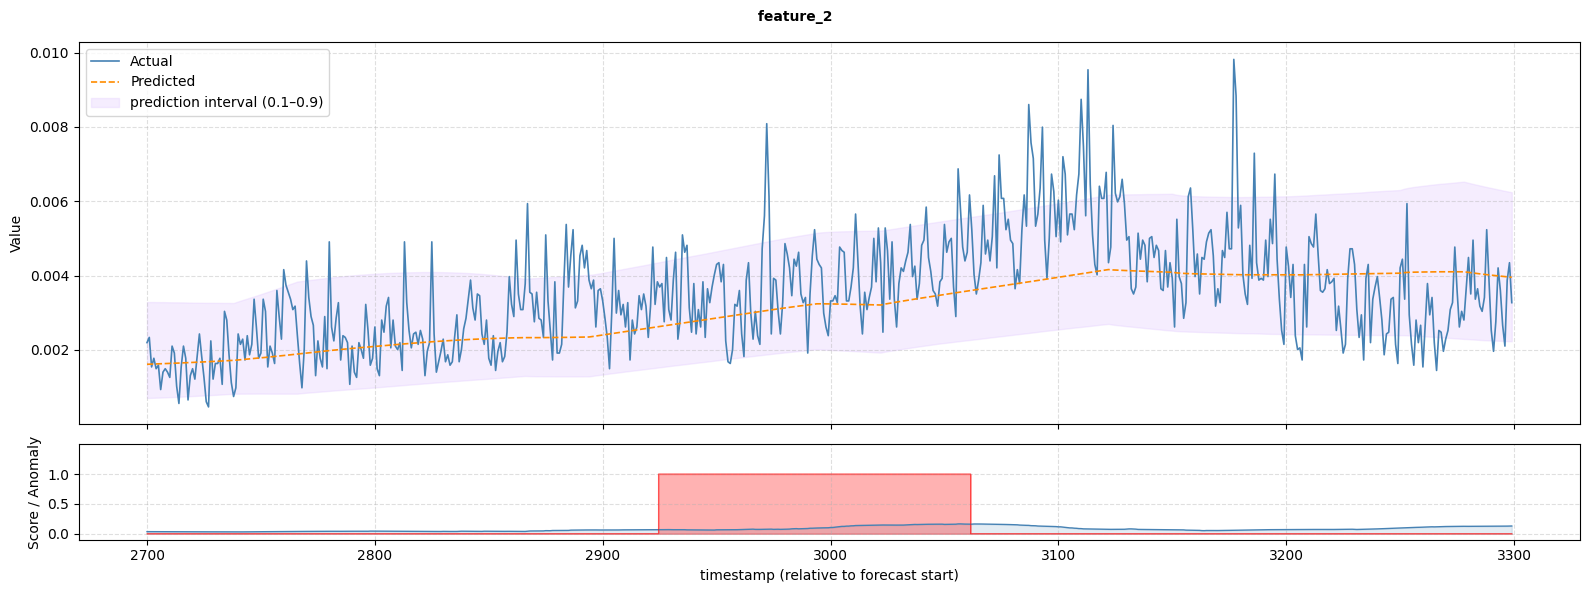

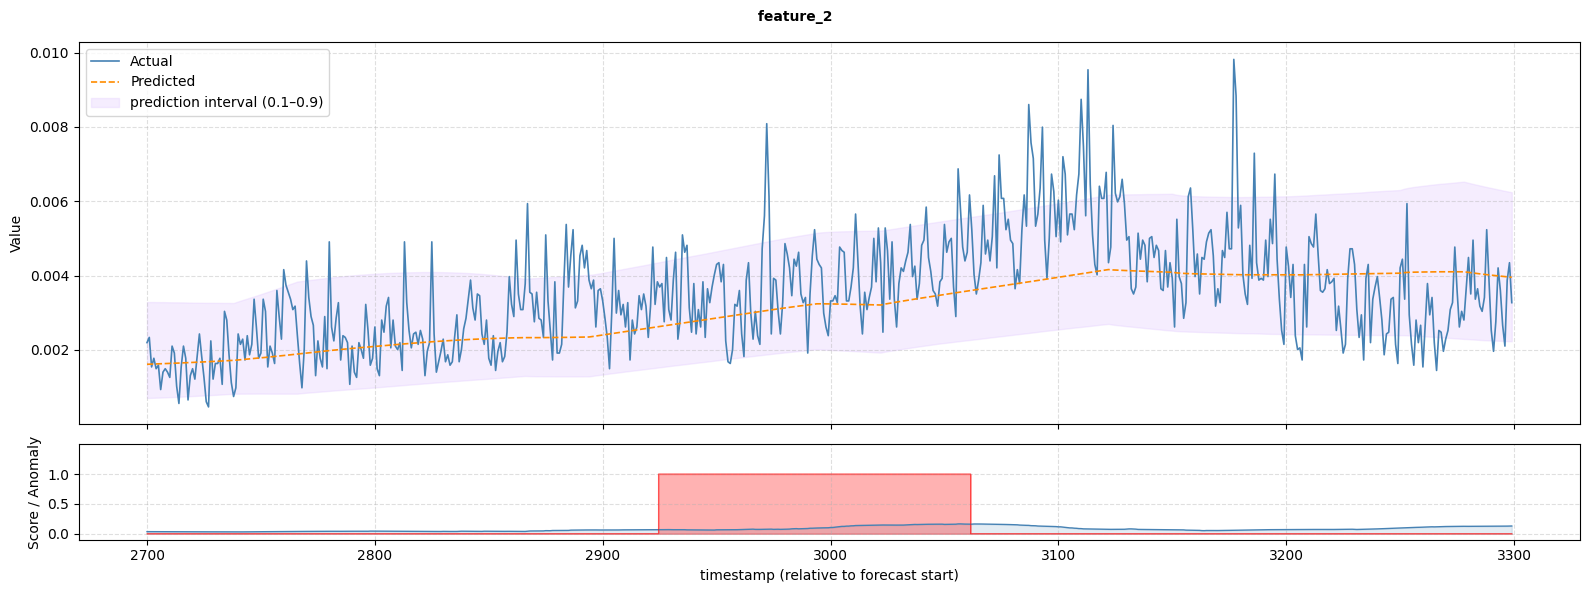

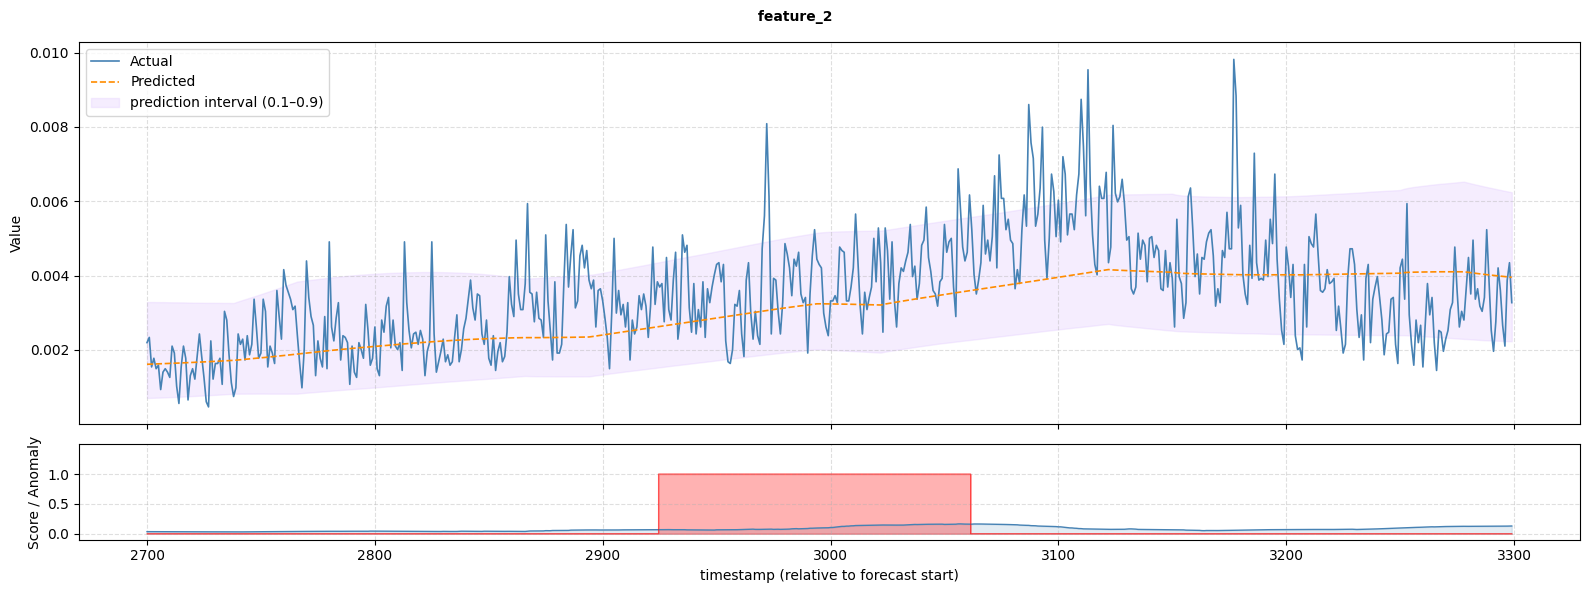

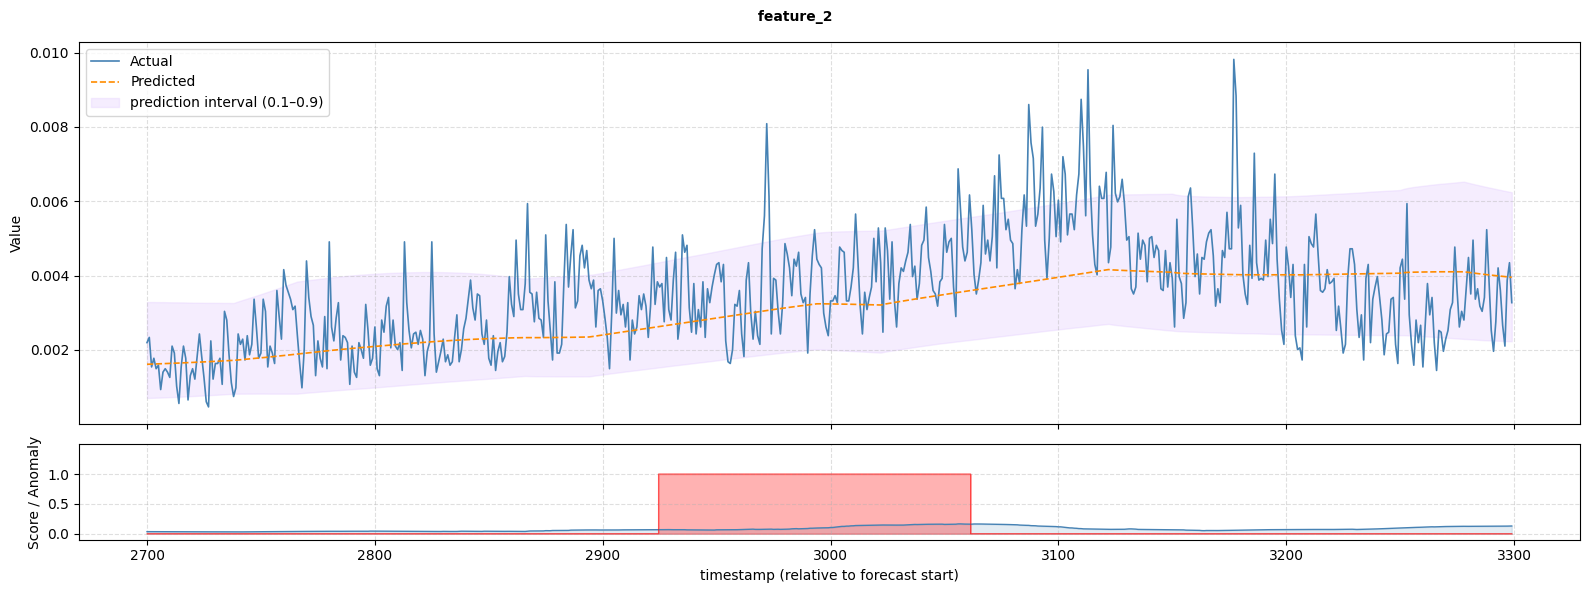

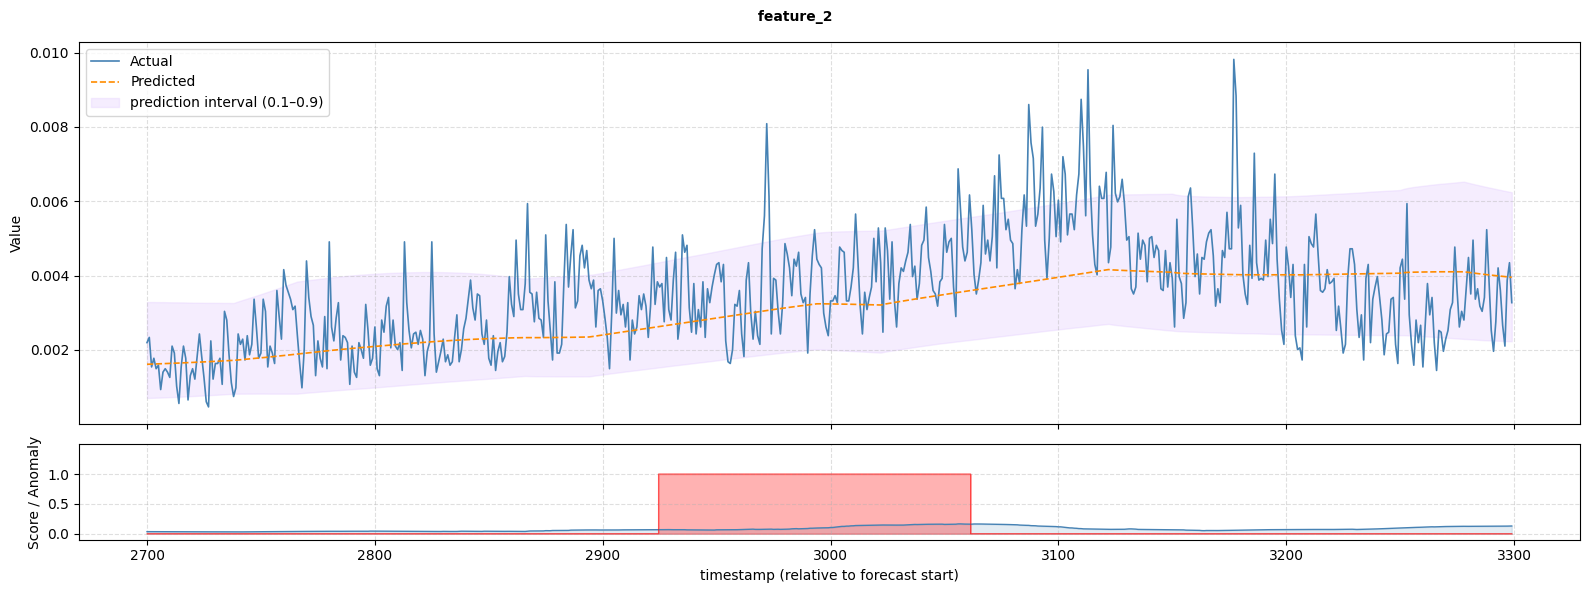

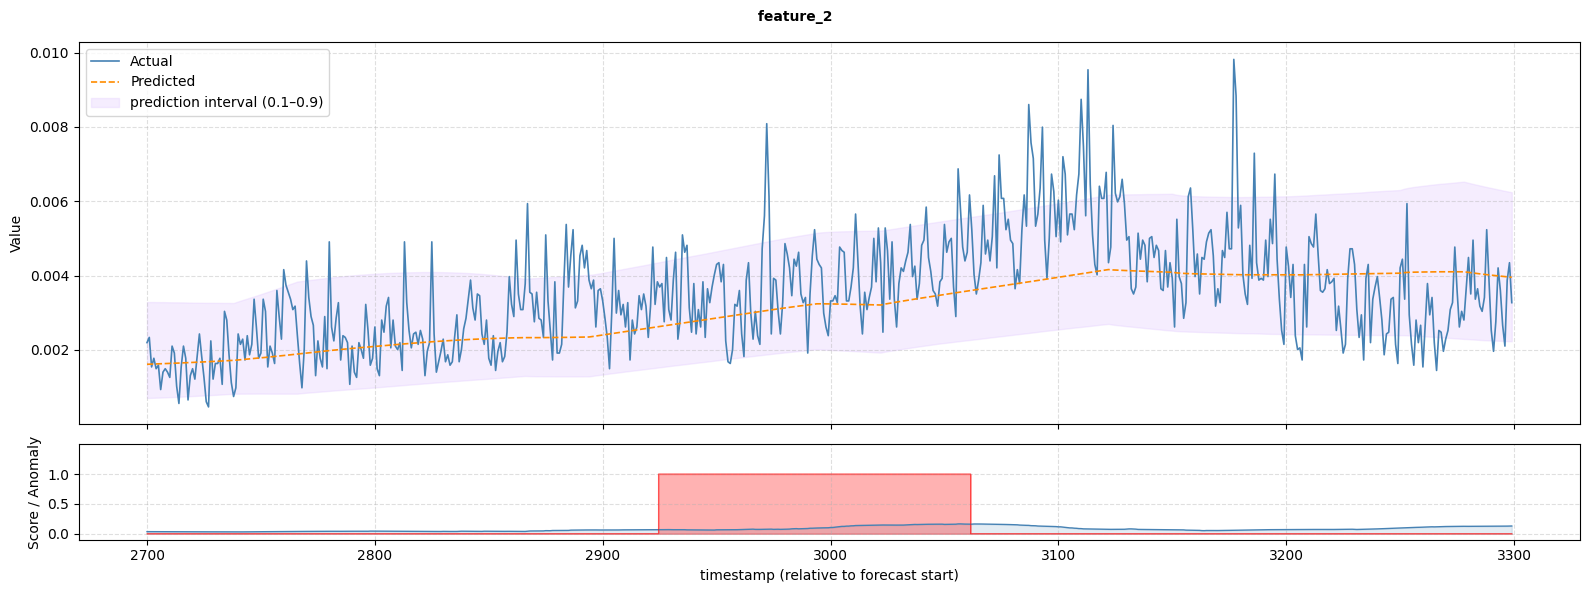

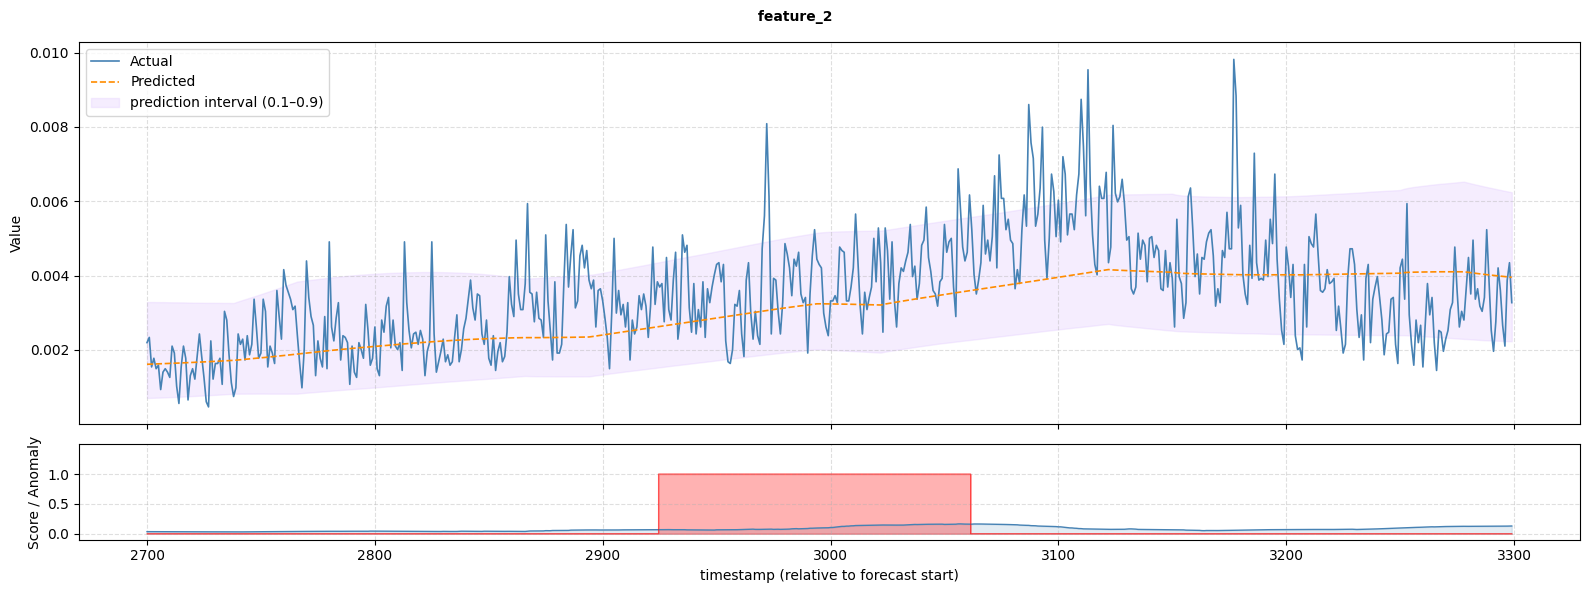

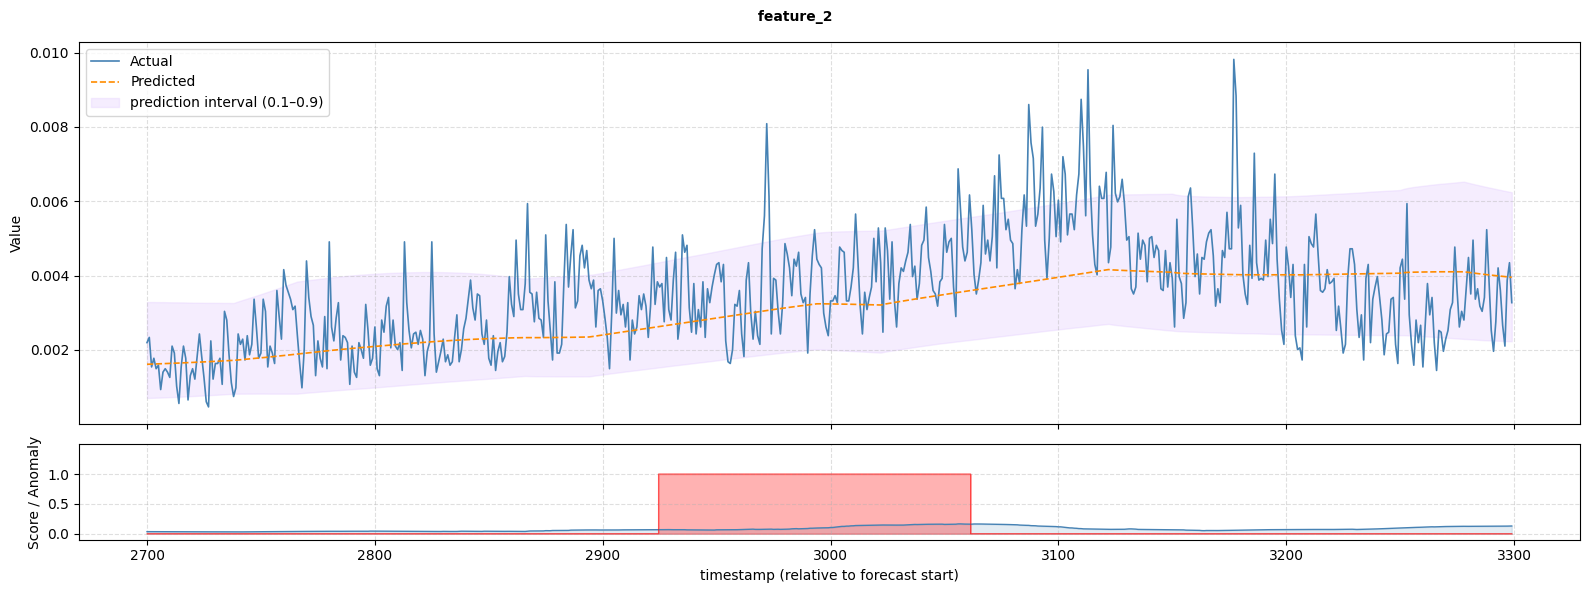

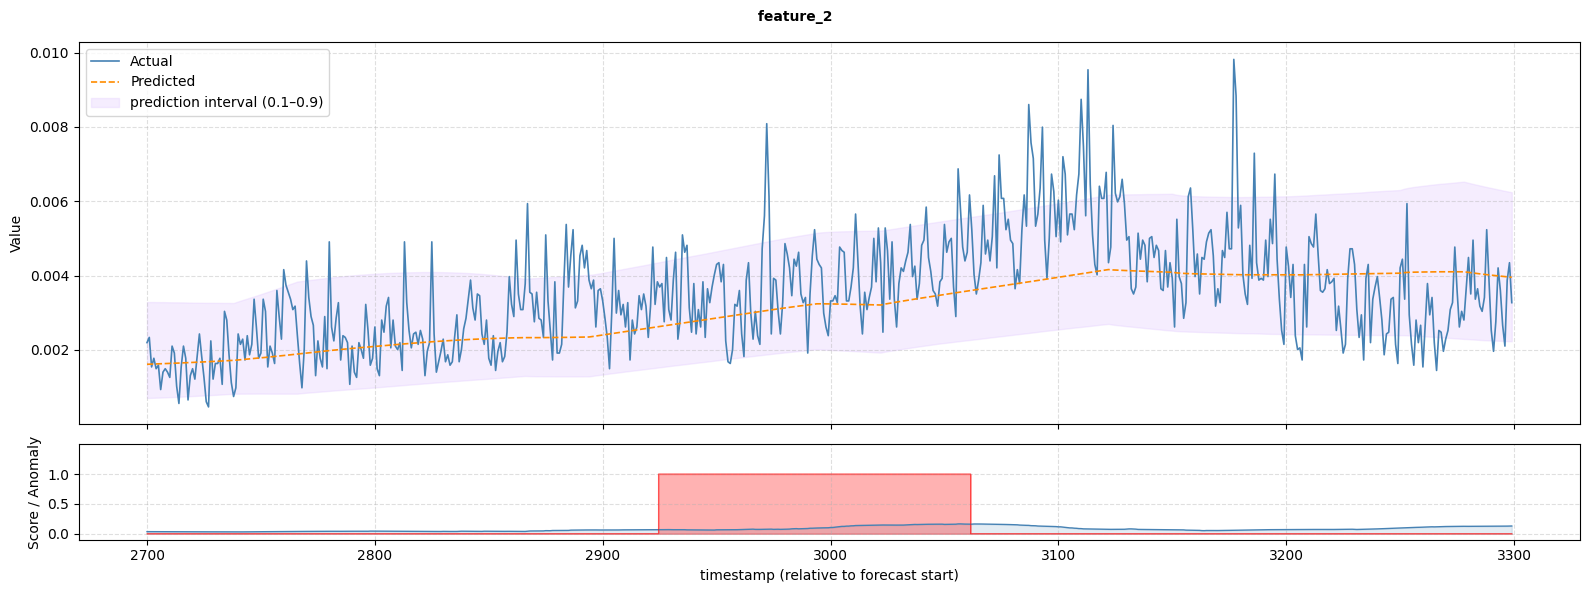

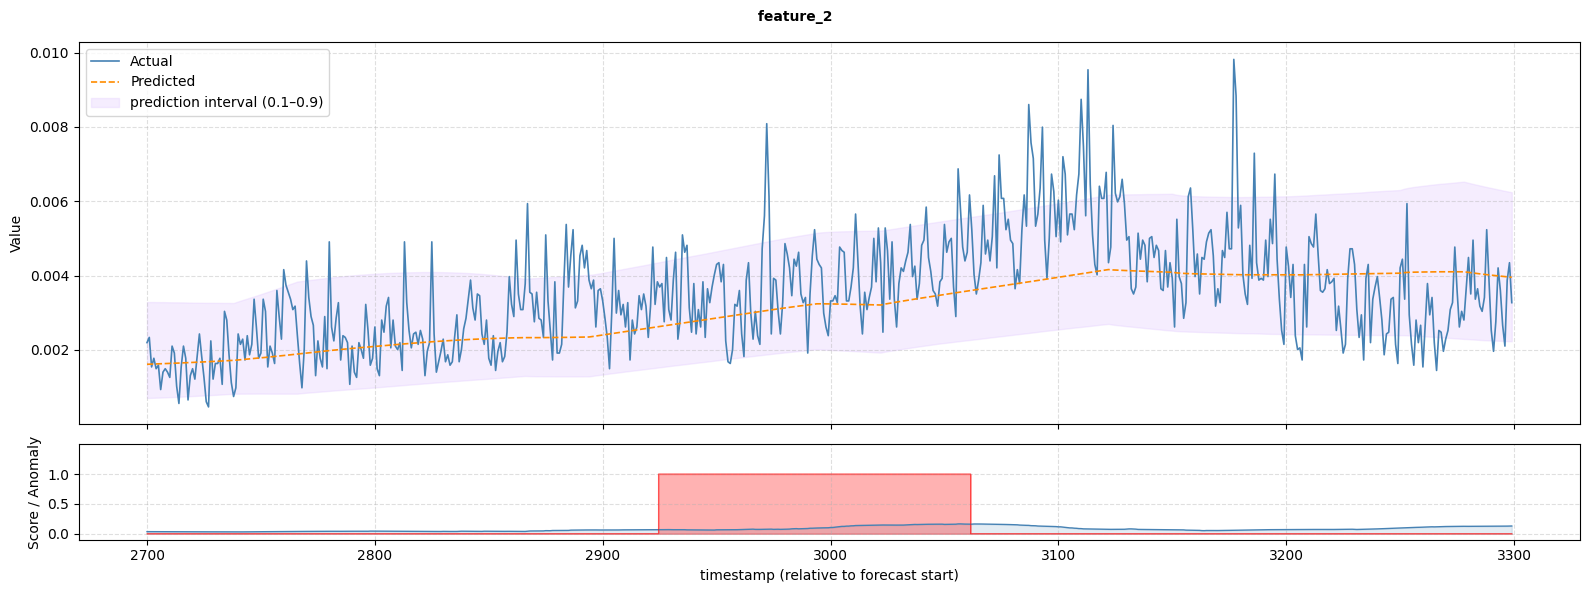

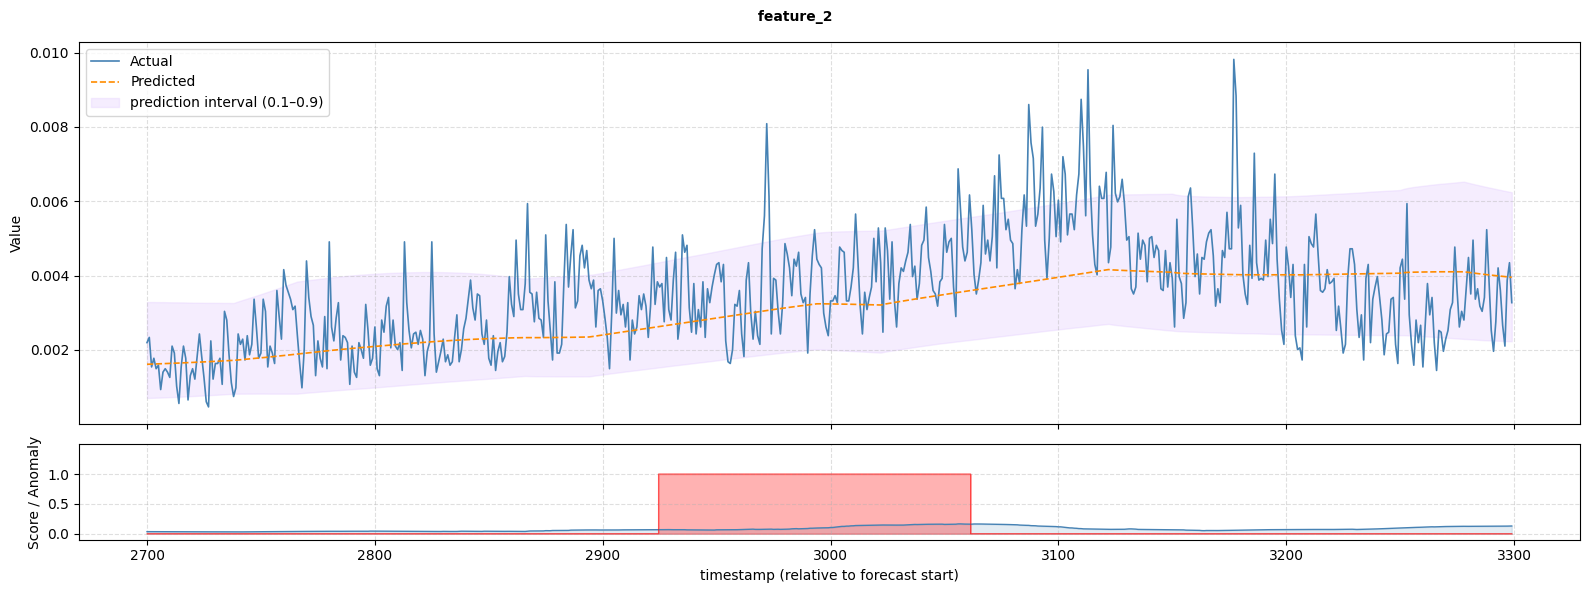

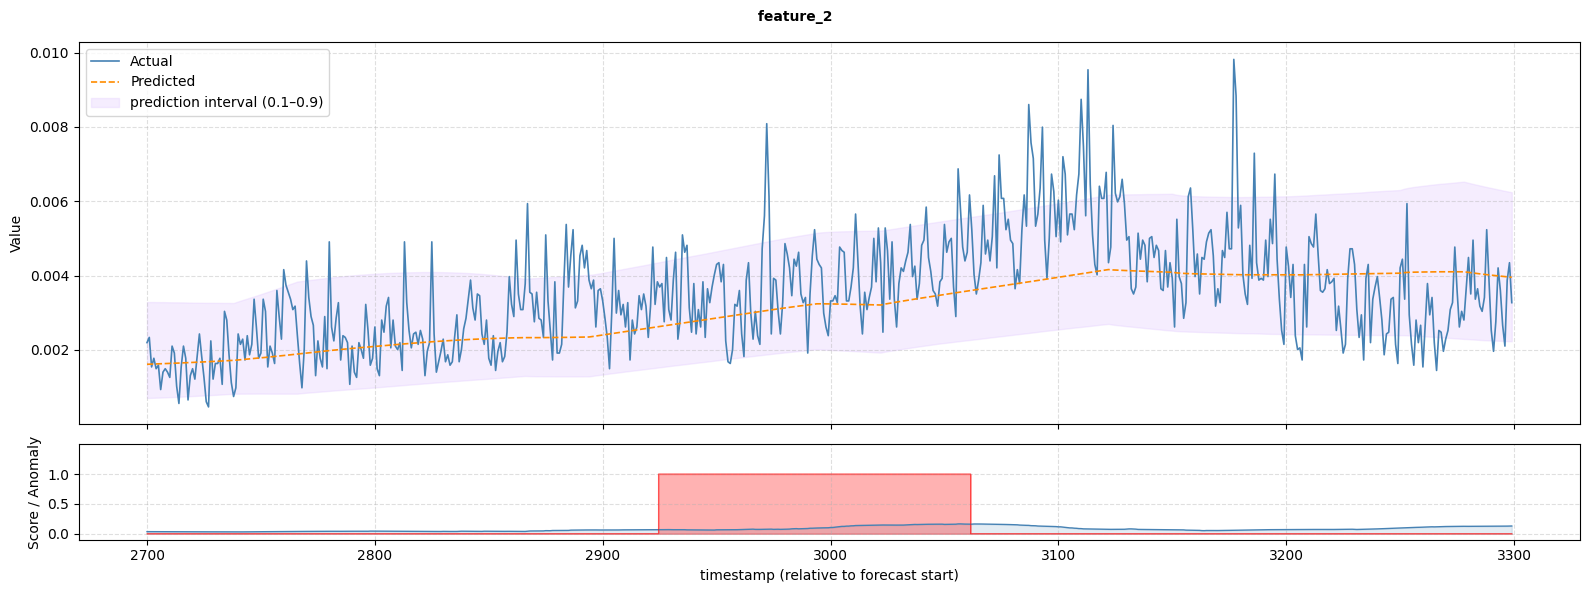

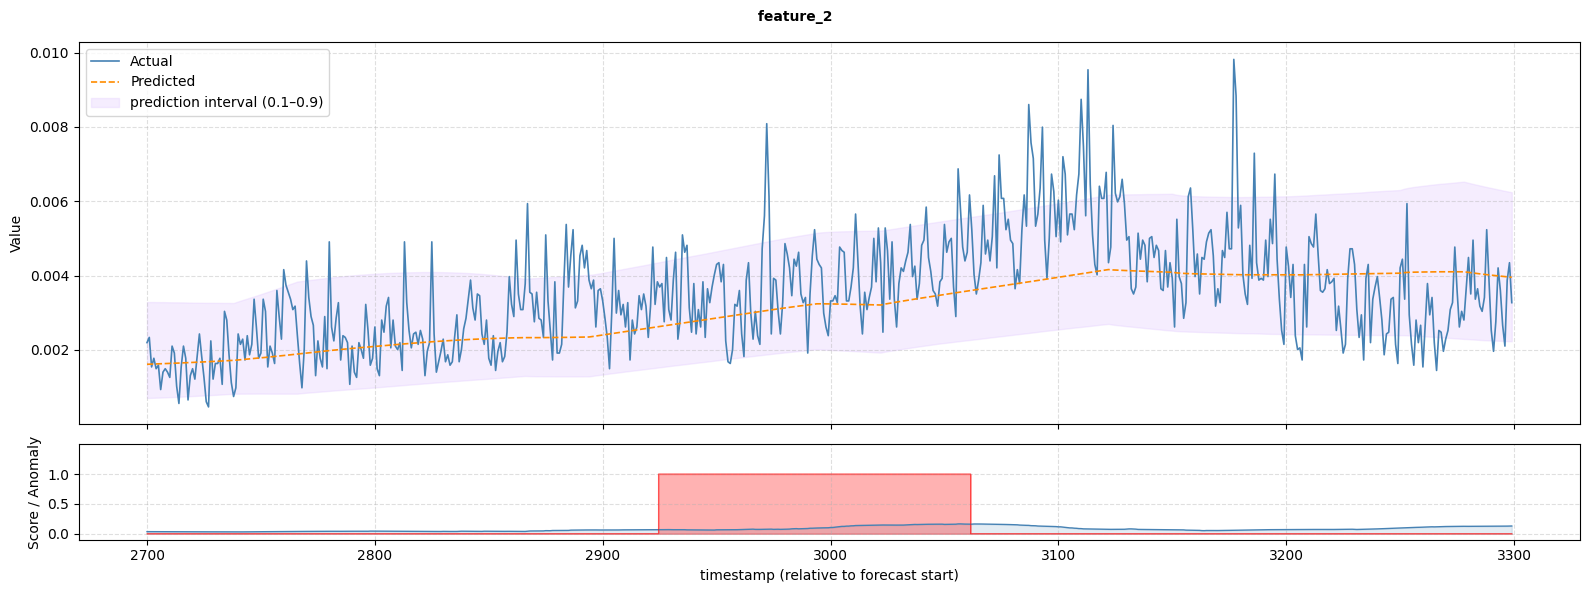

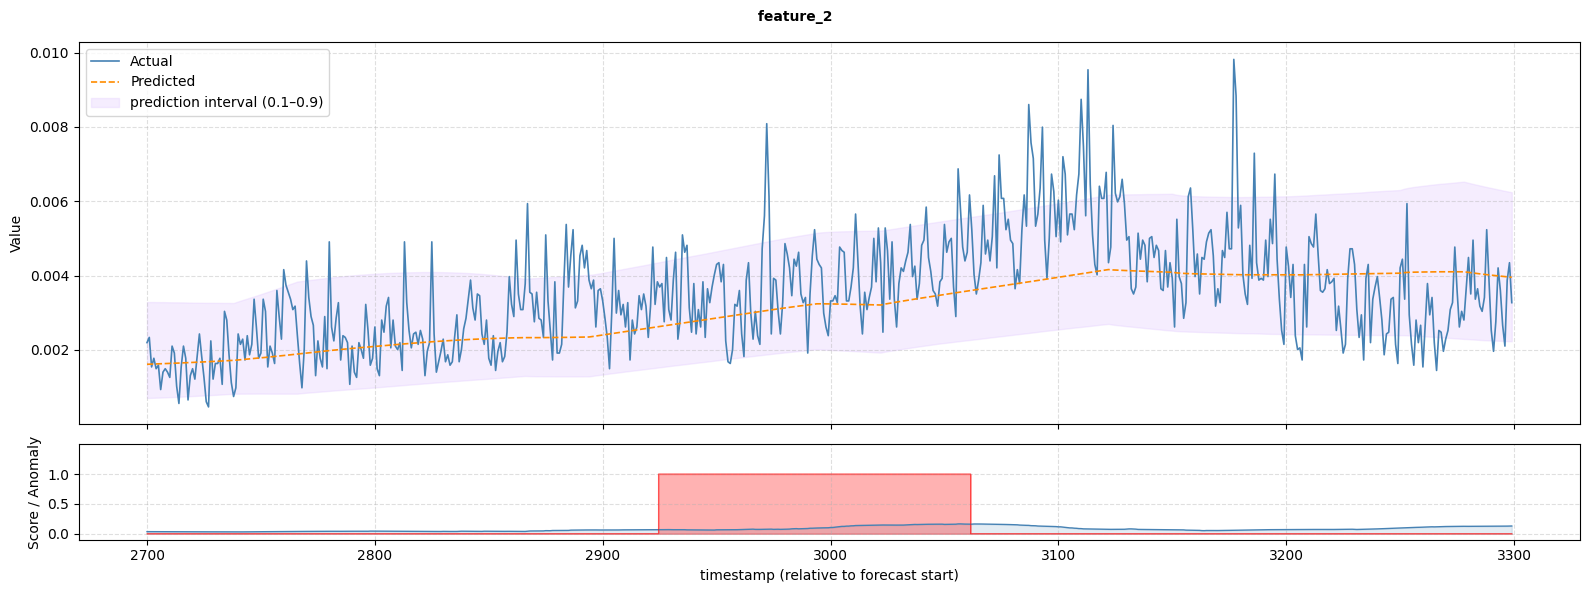

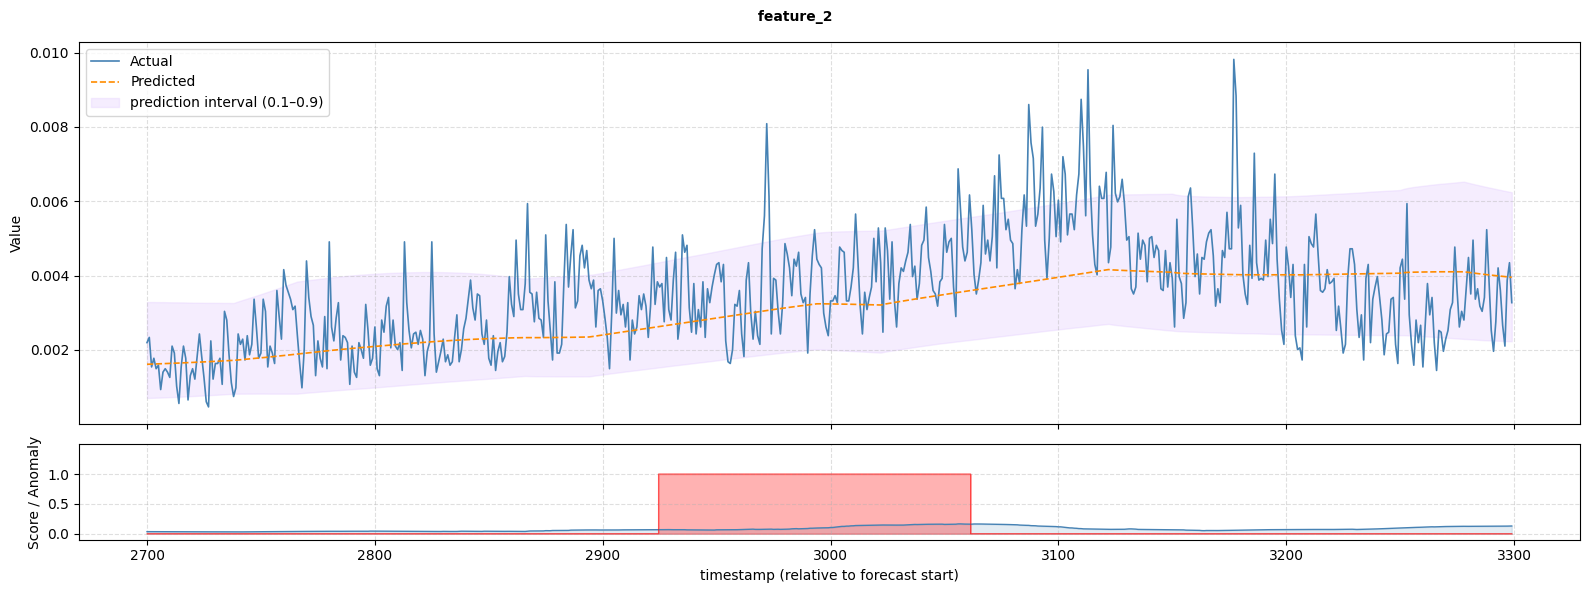

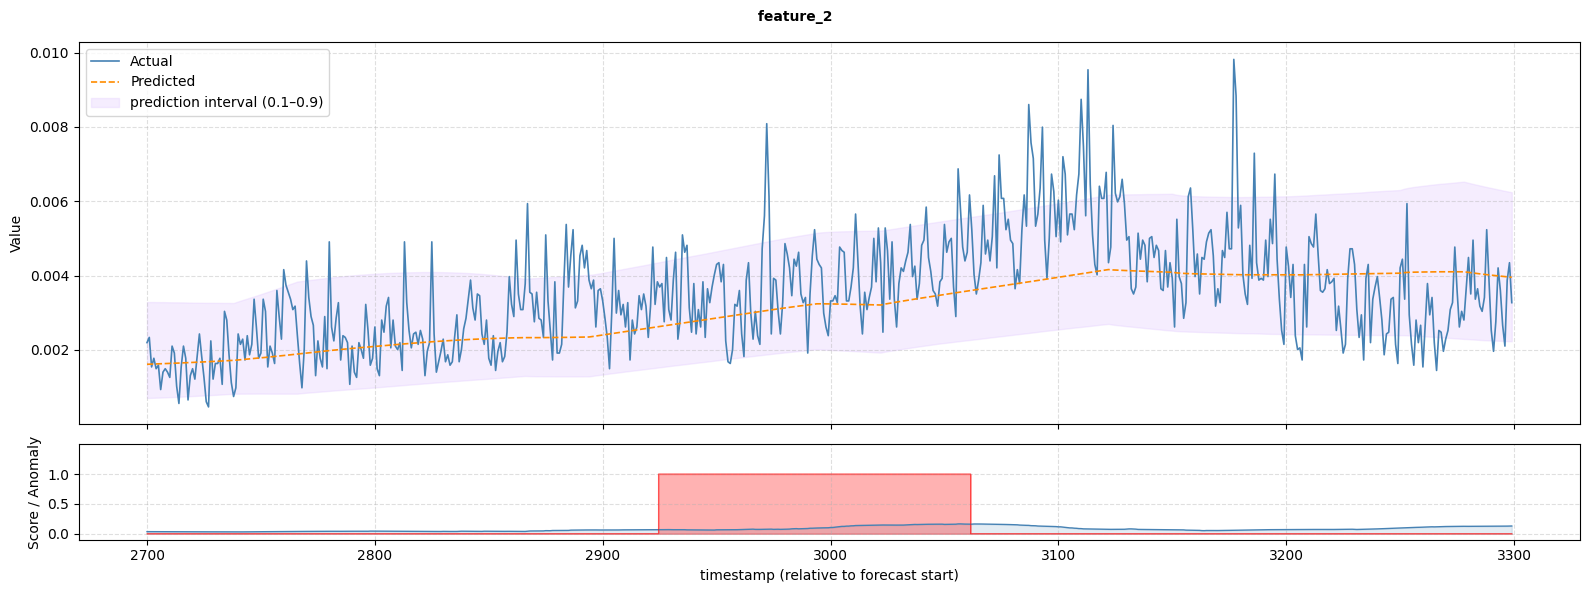

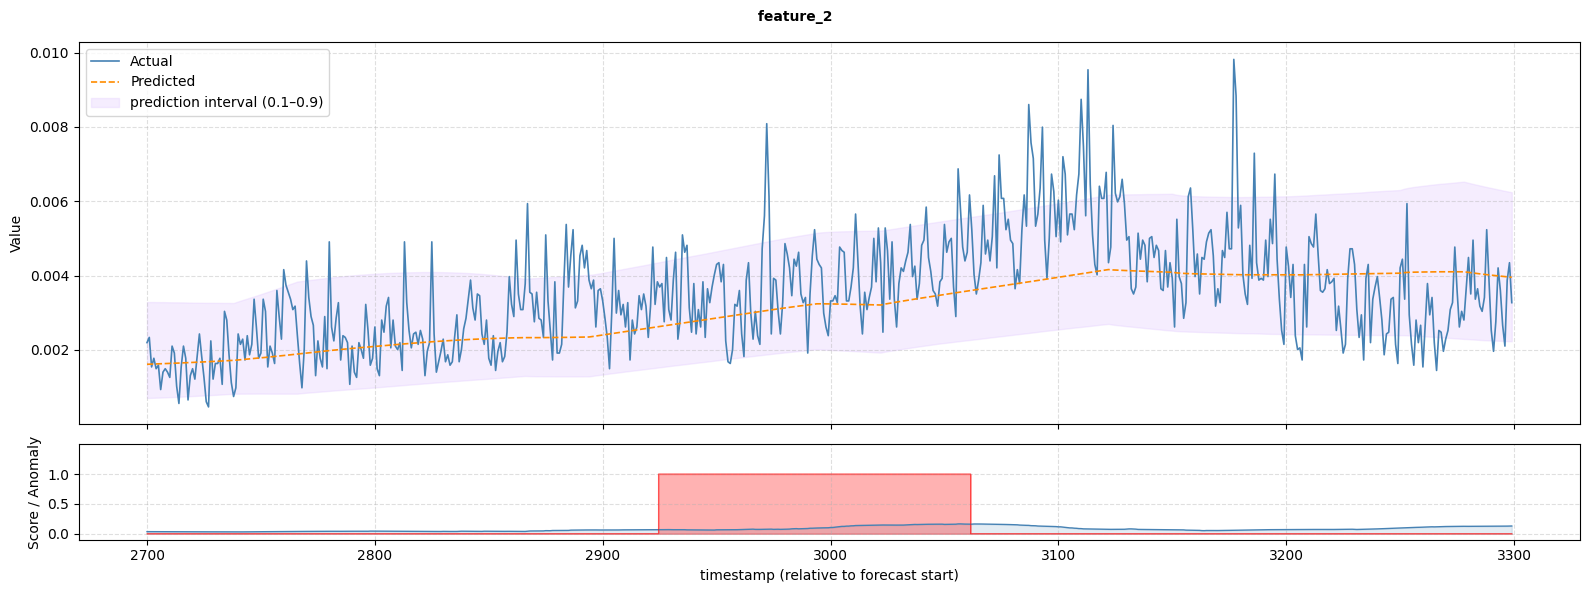

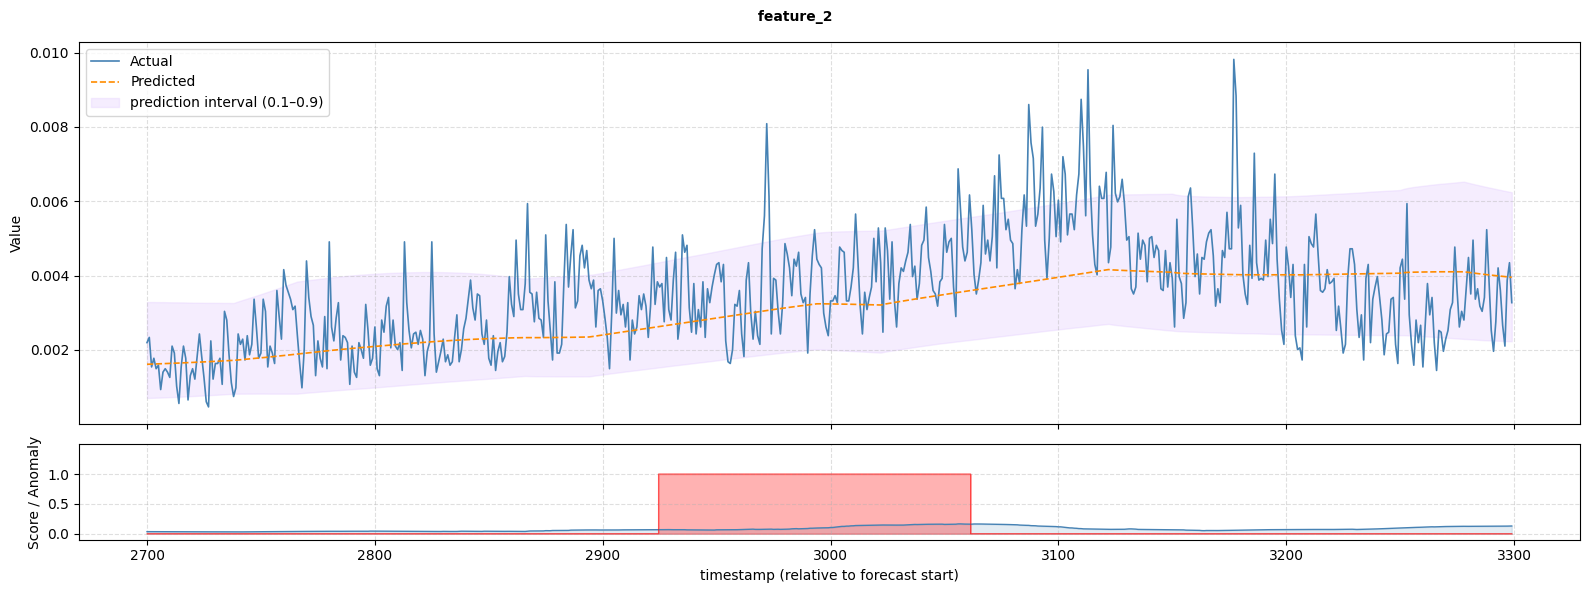

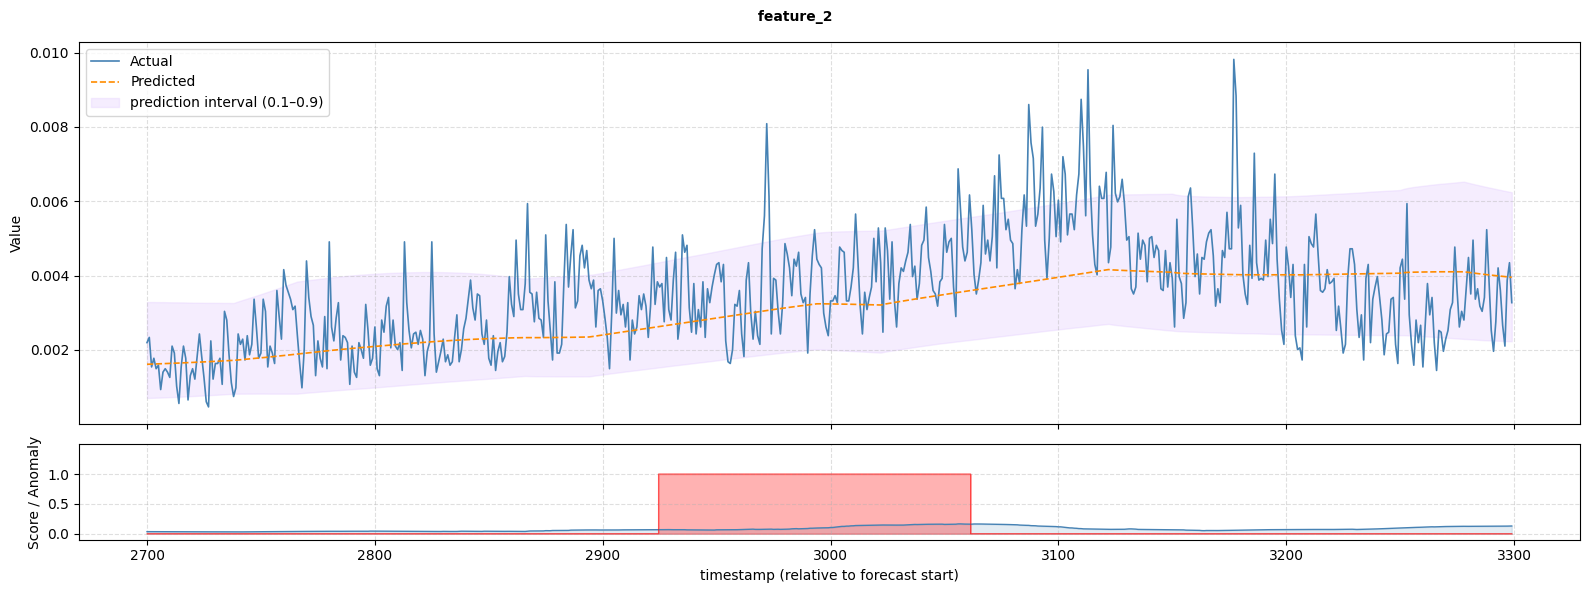

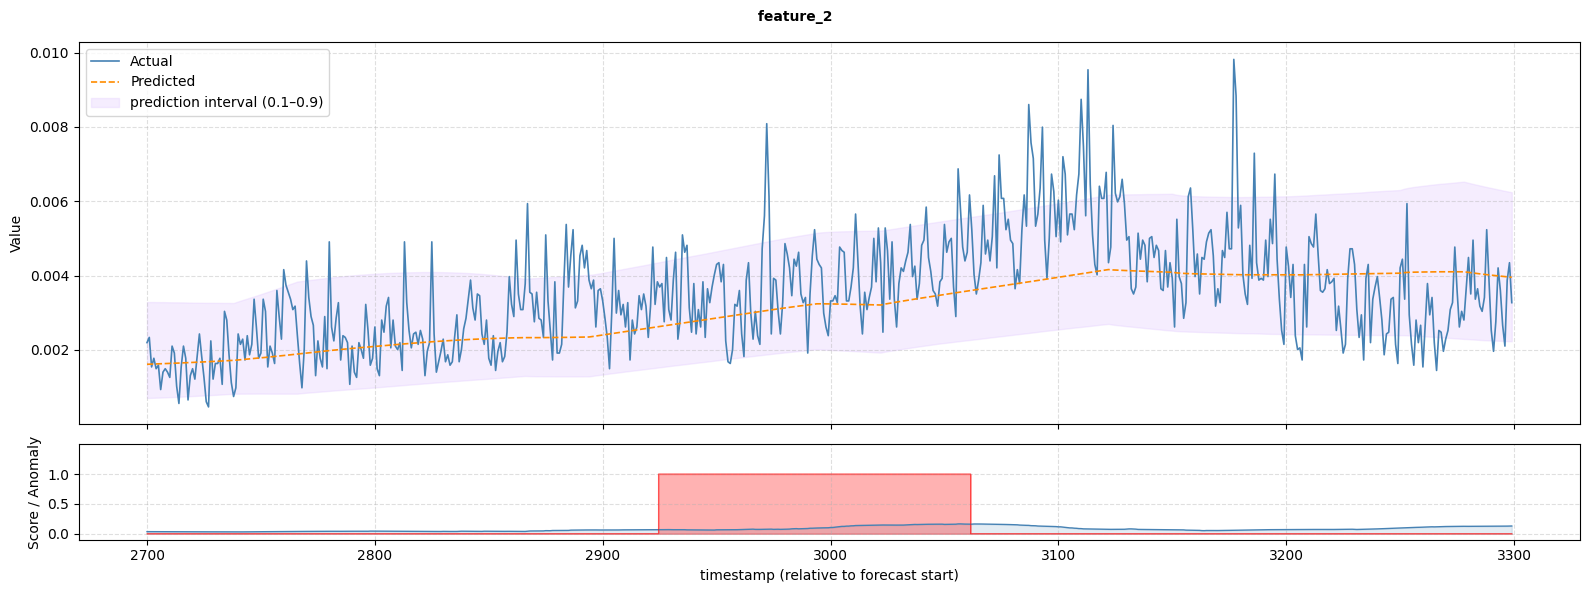

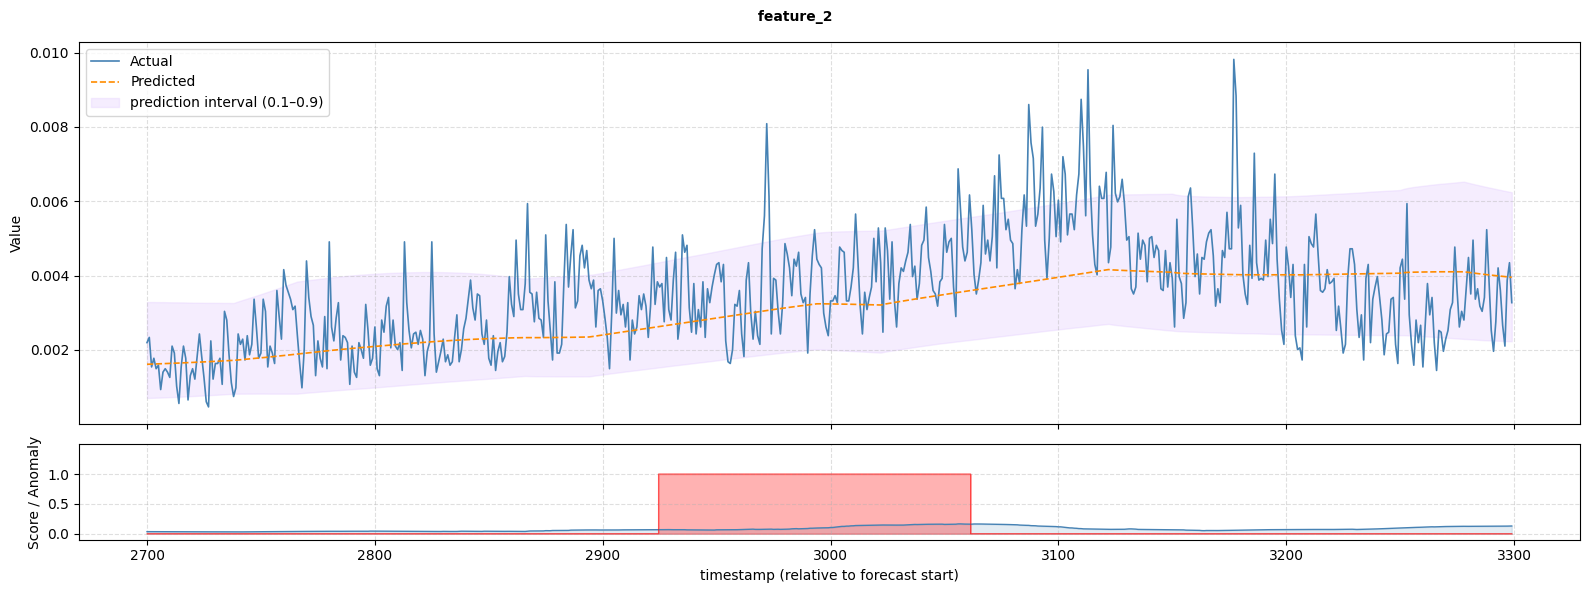

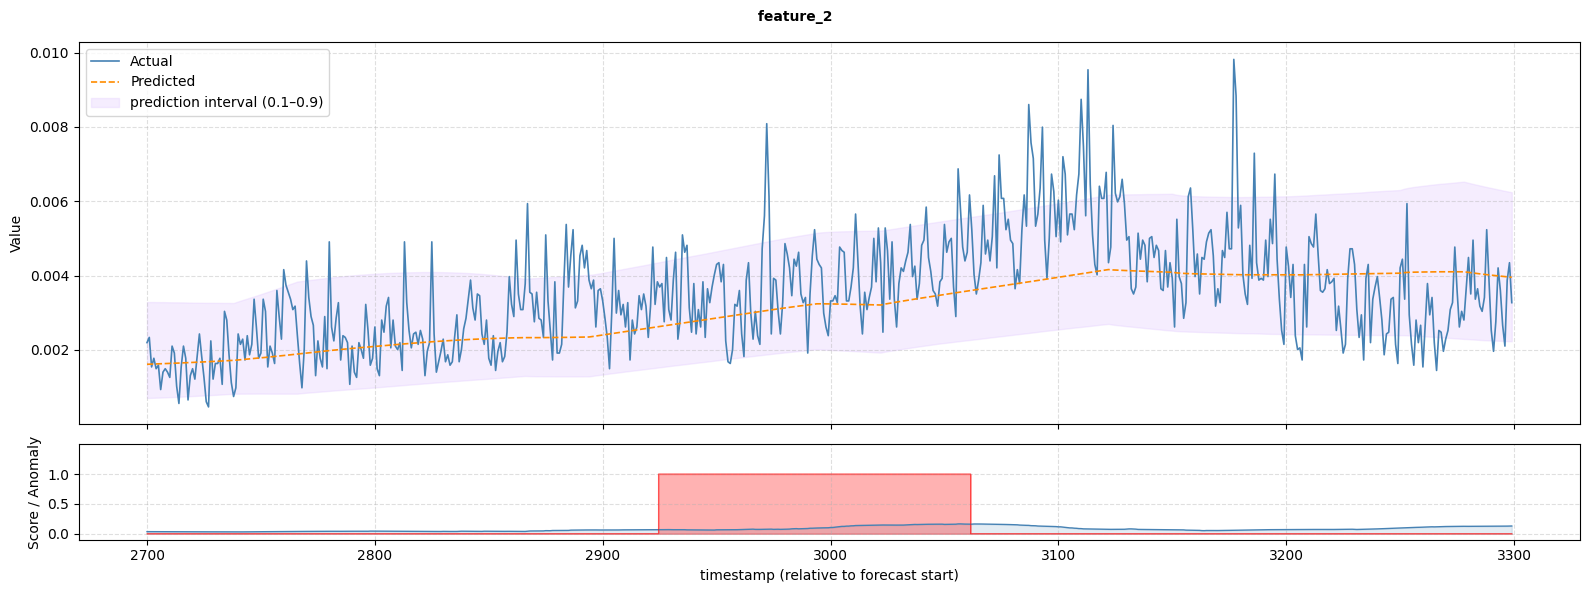

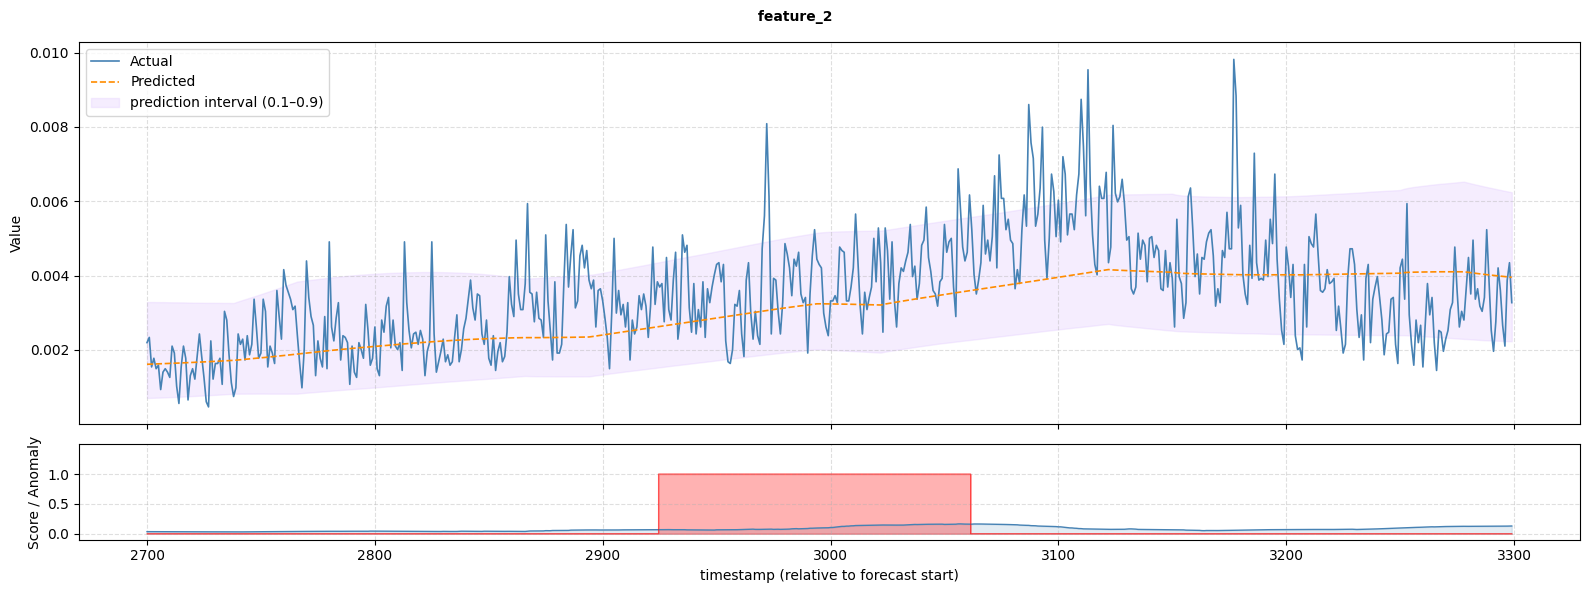

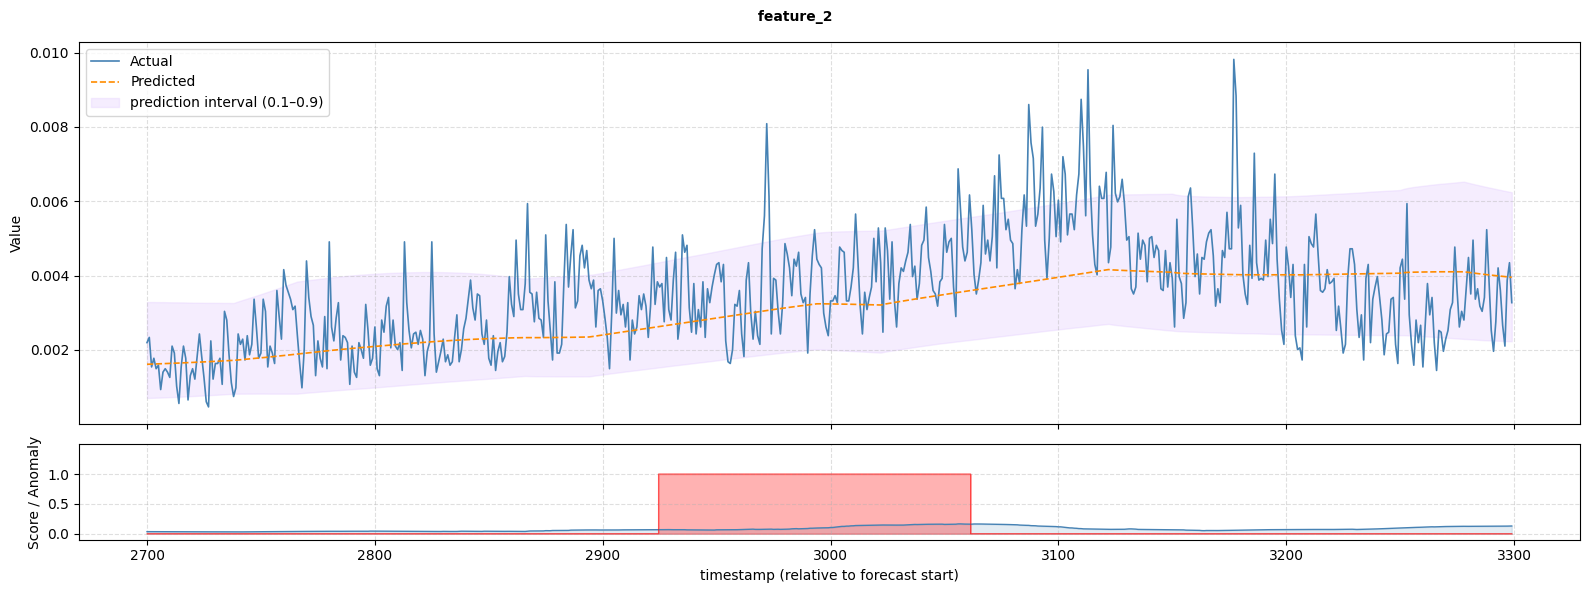

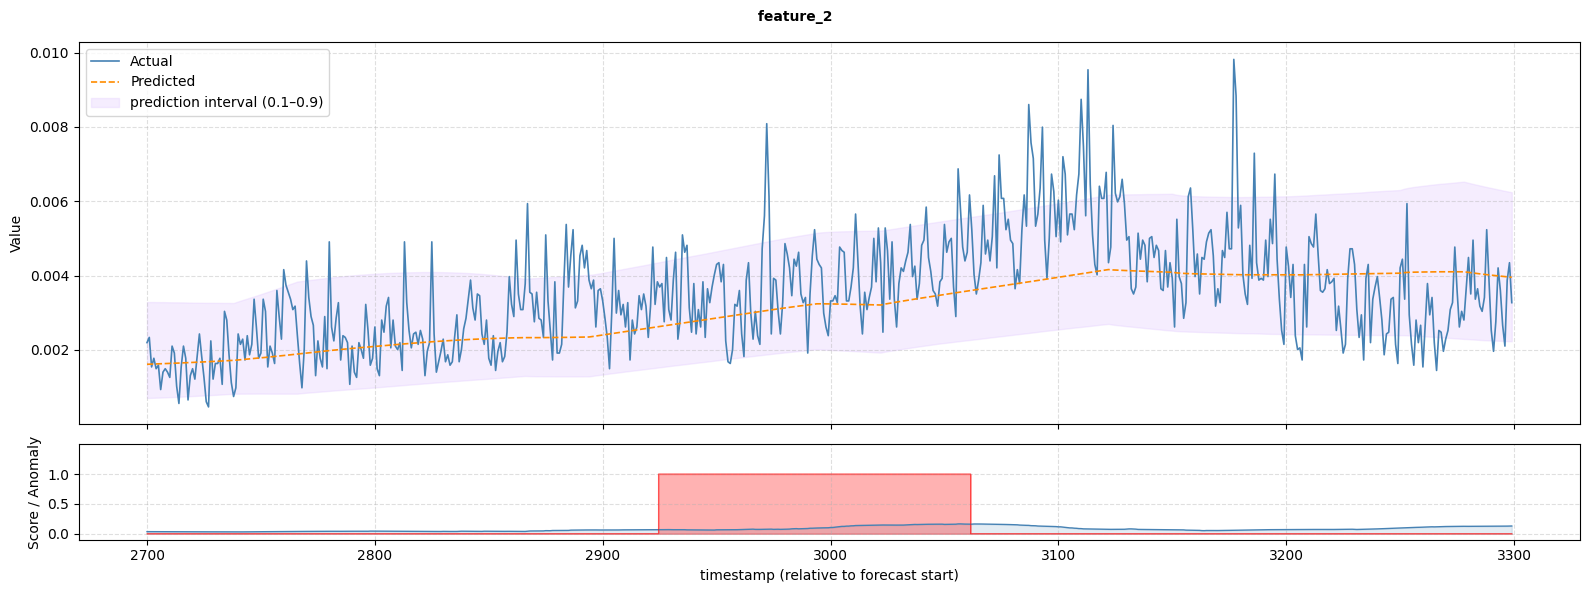

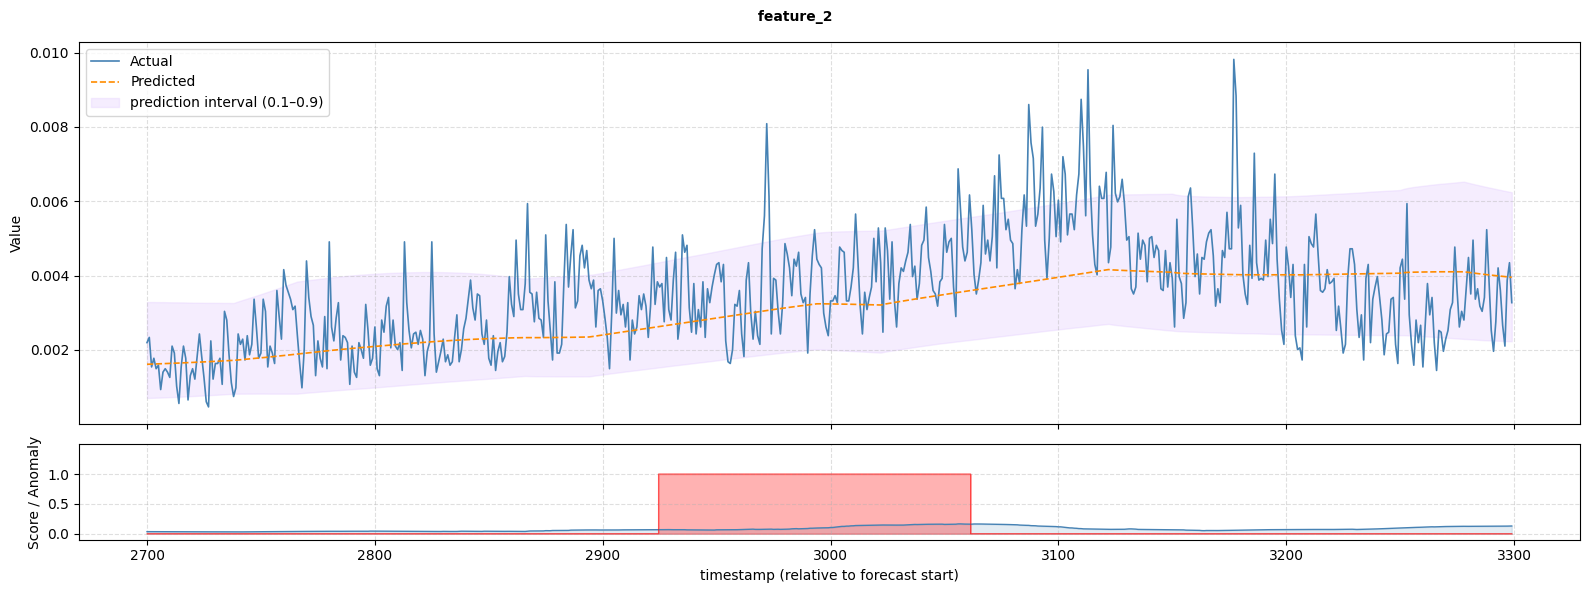

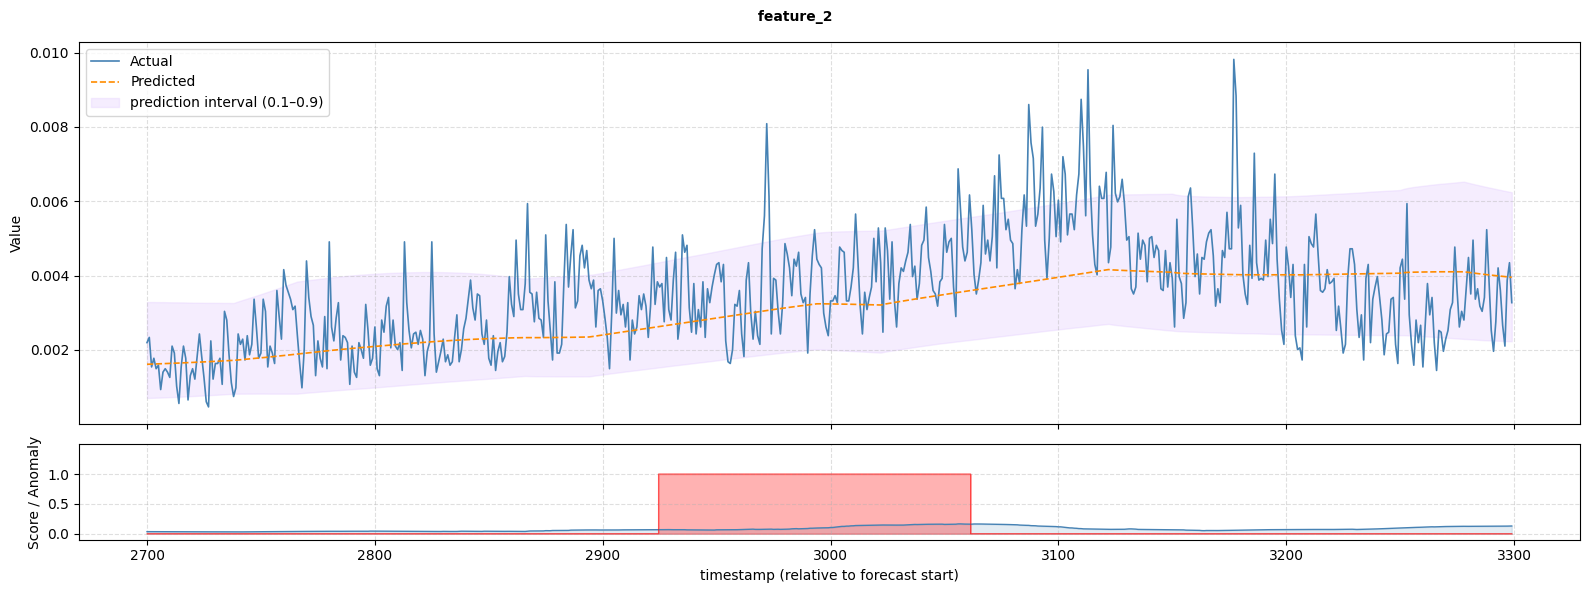

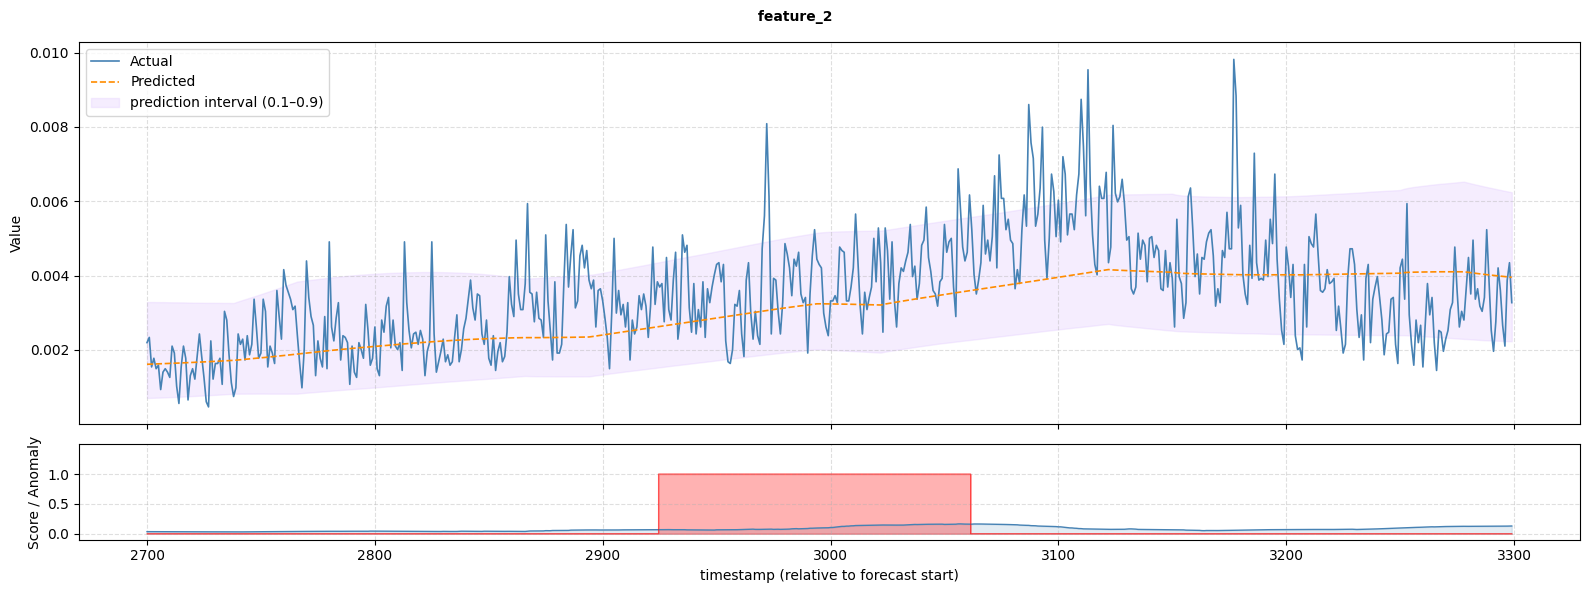

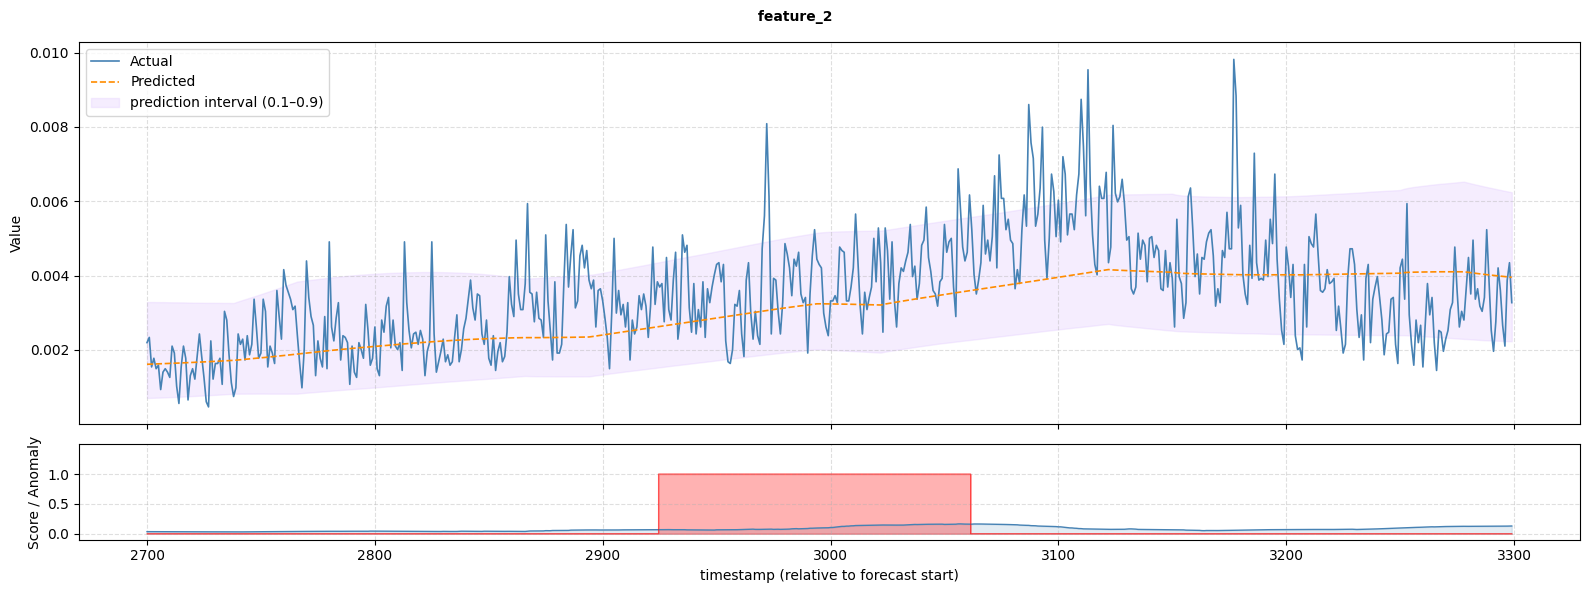

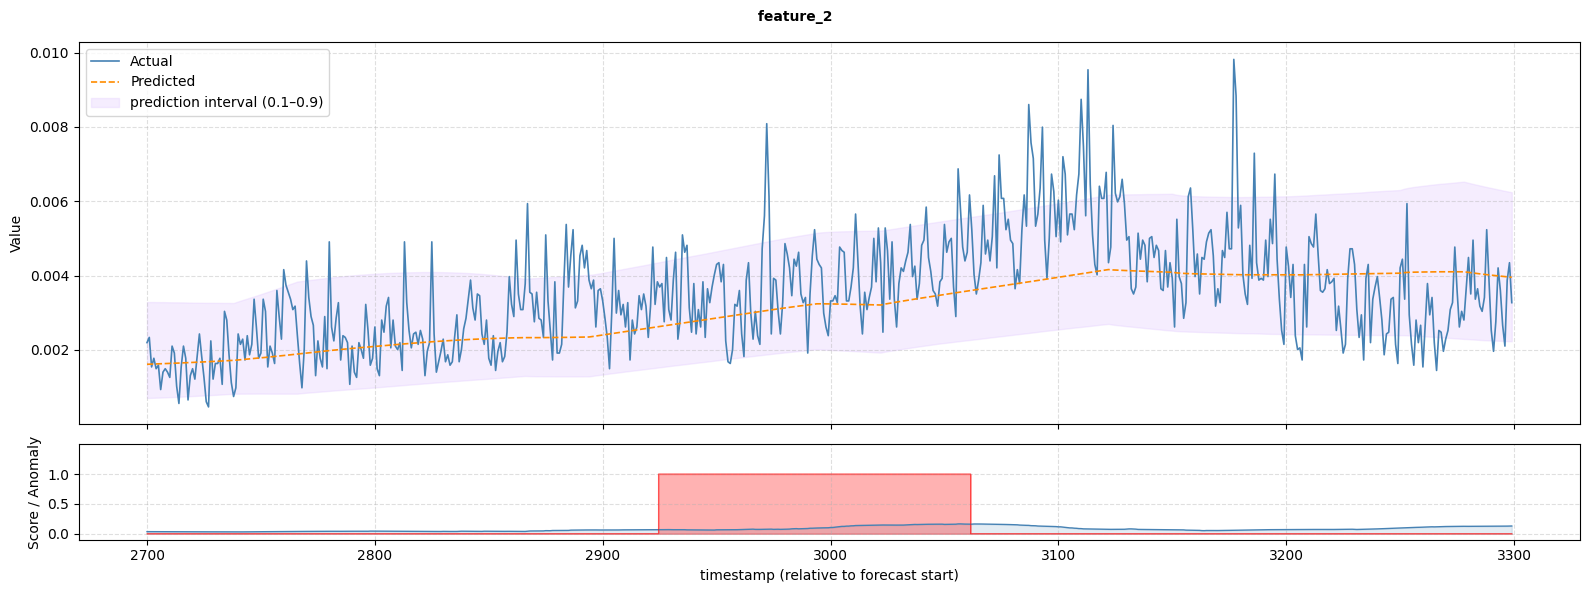

In [51]:
for i in range(len(feature_list)):
    plot_forecast_with_anomaly(
        feature_groups, df, y_score, label, feature_list,
        feature_idx=1,
        plot_from=2700,
        plot_until=3300,
        smooth_window=100,
    )

### Full Forecast Region (no zoom)

Set `plot_from`/`plot_until` to `None` to see the entire forecast region. Useful for an initial overview.

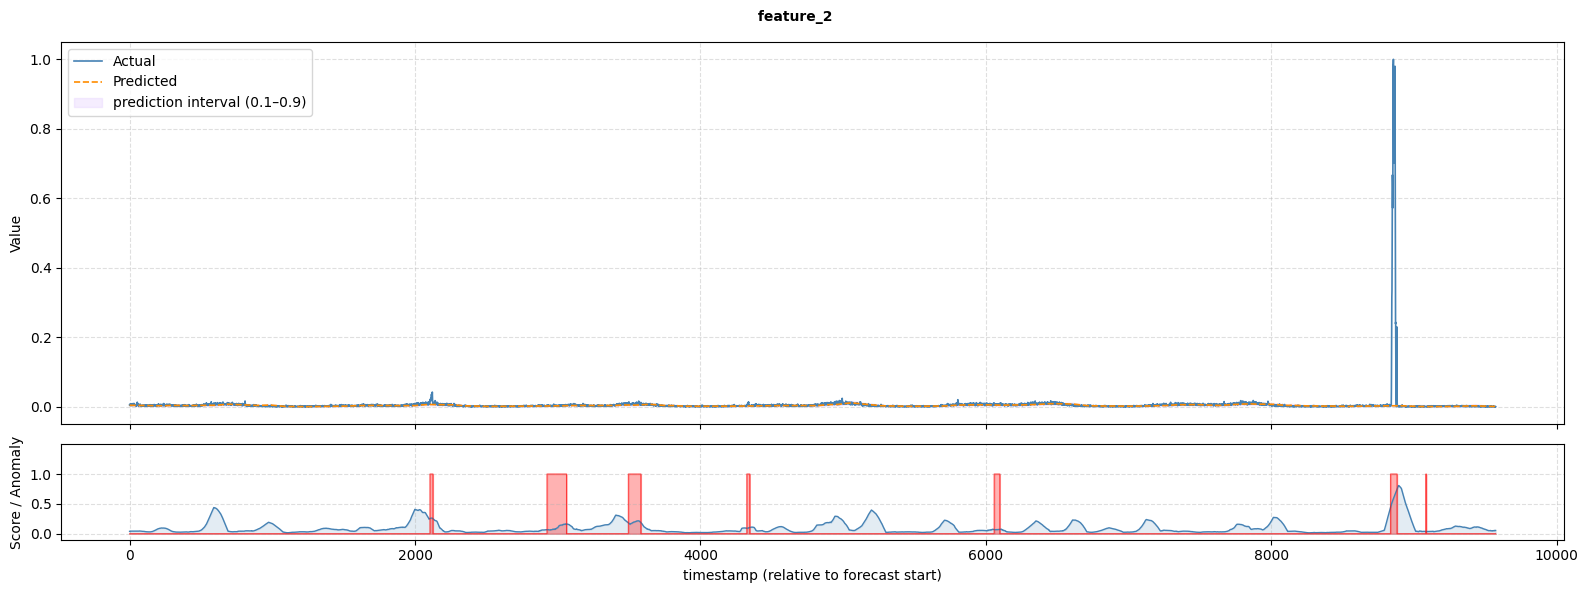

In [52]:
plot_forecast_with_anomaly(
    feature_groups, df, y_score, label, feature_list,
    feature_idx=1,
    plot_from=None,
    plot_until=None,
    smooth_window=100,
)